# Recall Analysis

This Notebook Aims at Analysing the Data from Recall Experiments. Computing Various Data Features anbd then Making Analysis out of it:





### Parameters 

In [433]:
### Imports
import matplotlib.pyplot as plt

EXPNAME = "secondExp"


### Parameters and Globals
CLASSN = 4                       # Number of MW Discrete Classess
DATAFOLDER = "data_second"       # Data Folder for experiment
LABELING = False                 # Labeling Mode
CLASSESS =  {1:"Focus",          # Classess Dictionairy t understand what means what
             2:"Task-Related Thoughts", 
             3: "Mind Wandering",
             4: "Mind Wandering"}

CONTINUE = True
VERBOSE = False
# FIlteri Data Parameters
SUBJECTS = "all"    
SHORTLEMMAS = True   # Whether to include Utterances that have simple to little Lemmas


VIZFOLDER = f"extrF_{CLASSN}_{SHORTLEMMAS}_{SUBJECTS}"


### Load Data

This is a part to load the data-frames of Previous Data and analyses as well as all the other important things

also for labeling if it is necessery 

In [434]:
####    Load Necessery Variables and Paths:
import os 
from storyTools import loadStory,splitStoryEntity,reLabel
import pandas as pd
import numpy as np 
import pickle

### General Working, Data, and Saving Path:
workingDir = os.getcwd();                                 # Current Folder
path = os.path.split(workingDir)[0] + "\\" + DATAFOLDER   # Data path
savePathRecall = os.path.join(workingDir,EXPNAME,'Recalls')       # Save Path for Recall results
savePathFeatures = os.path.join(workingDir,EXPNAME,'RecallAnalysis',VIZFOLDER)

if os.path.isdir(savePathFeatures) == 0:
    os.makedirs(savePathFeatures) # Create a directory for recall results

subjects = [f for f in os.listdir(path) if  not os.path.isfile(os.path.join(path, f))]  # get all the filenames


### Get Polish Stopwords:
with open(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\polish.stopwords.txt", encoding="utf-8") as f:
    polish_stopwords = set(line.strip().lower() for line in f if line.strip())



if CONTINUE and not LABELING:
    with open(os.path.join(savePathFeatures ,"topic_model_logreg.pkl"), "rb") as f:
        classifModel = pickle.load(f)

### Load Previous Excel File with Data:
dfData = pd.read_excel(os.path.join(savePathFeatures,"data.xlsx"), index_col=0)

### Create other Data Frames
if not os.path.isfile(os.path.join(savePathFeatures,"features.xlsx")):
    dfAnalysis = dfData[['Subject','Fragment','Attention','utt_leng']] # Data Frame for Analysis


### Change Classess for a 2 way classification:
#### RE-Teaching on Binary Classification: 
if CLASSN == 2:
    dfData = reLabel(dfData,renameDict={1:1,1:2,3:3,3:4})
    dfData = reLabel(dfData,renameDict={1:1,2:3})
    CLASSESS =  {1:"Focus", 2:"Mind Wandering"}




## Preprocessing 

This Part of Code Gathers Data and Functions that are Paramount for Analysis

Here we preprocess our data so it would be clean for our future Analsis and Teaching: 
0. Create Labels - (Optional)
1. Loading ALL Recall Texts - Gathering all Corpus Data
2. Loading All Stories
3. Making Morphological Entities extraction from Both Stories and Recalls

#### Create Labels and Explore: (Optional)

Here we Label our Data based on 4 classess - it is done only ones




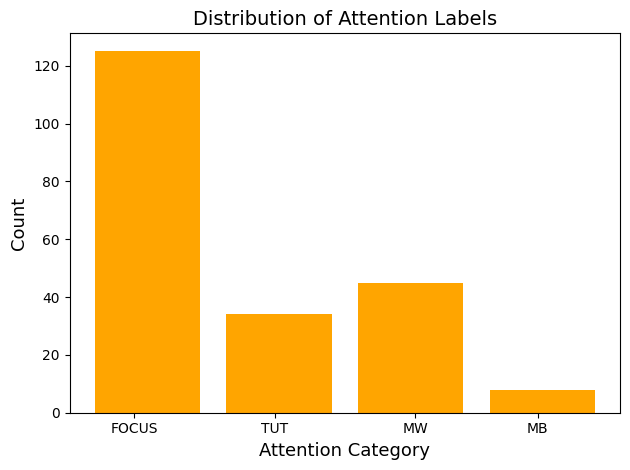

Subject                      ADNA2507    ANLU2607   JUBE2907   MANI2607  \
Attention Desc      1       29.000000   26.000000  13.000000   19.00000   
                    2        6.000000    7.000000   0.000000   15.00000   
                    3        5.000000    5.000000   4.000000    6.00000   
                    4        0.000000    2.000000   0.000000    0.00000   
Utterance Leng Desc count   40.000000   40.000000  17.000000   40.00000   
                    mean   161.800000  175.275000  40.058824  167.32500   
                    std     41.159602   66.551691   7.453779   59.80026   
                    min    104.000000   44.000000  30.000000   62.00000   
                    25%    126.500000  132.000000  33.000000  123.50000   
                    50%    163.500000  178.000000  40.000000  153.50000   
                    75%    189.250000  227.500000  43.000000  207.75000   
                    max    298.000000  311.000000  57.000000  275.00000   

Subject                      NIZA2907    PIKR2907  
Attention Desc      1       14.000000   24.000000  
                    2        6.000000    0.000000  
                    3       16.000000    9.000000  
                    4        4.000000    2.000000  
Utterance Leng Desc count   40.000000   35.000000  
                    mean   327.275000  124.285714  
                    std    108.052453   63.871918  
                    min     71.000000   43.000000  
                    25%    253.250000   69.500000  
                    50%    349.000000  111.000000  
                    75%    406.250000  160.000000  
                    max    530.000000  328.000000

<Figure size 640x480 with 0 Axes>

In [ ]:
import ast

labeledSubjects = dfData['Subject'].unique()
subjR = [ f.name for f in os.scandir(savePathRecall) if f.is_dir() ]

from IPython.display import clear_output
if LABELING:
    answer = []
    answDict = {}
    answrScheme = {v: k for k, v in CLASSESS.items()}

subjList     = []
fragmentList = []
rawCorpus    = []

for sn,s in enumerate(subjR):

    textfiles = [f for f in os.listdir(os.path.join(savePathRecall, s)) if f.endswith('.txt') and 'recall_' in f[:7] and "KASIA" not in f]
    answDict[s] = []
    if CONTINUE and (s in labeledSubjects): # Label only unlabeled Subjects - Creates a NEW DataFrame
        continue
    for t in textfiles:
        text_file =  open(os.path.join(savePathRecall,s,t), "r+",encoding="utf-8")
        fragmentList.append(os.path.splitext(t)[0])
        subjList.append(f'DS{int(m.group(1)):02d}')

        for line in text_file: # One Text - One Line: Always! - thats why it worrks although it looks INCREDIBELY SKETCHY
            rawCorpus.append(line) 
            if LABELING:
                print(f"Text of {os.path.splitext(t)[0]} from {s}",flush=True)
                print(line,flush=True)
                ans = input()
                answer.append(ans)
                answDict[s].append(ans)
                clear_output()
            else:
                if CONTINUE: # IF no labeling BUT continue, means that We need to fill by Blanks
                    answer.append(None)
                else: # If No Labeling and No continue, we need to fill previous iteration from our DF
                    answer.append(dfData['Attention'][(dfData['Subject'] ==s) & (dfData['Fragment'] == os.path.splitext(t)[0])].values[0])
import pandas as pd
if len(rawCorpus): #If there are  New Subjects
    dfData= pd.DataFrame([subjList,fragmentList,answer,rawCorpus],index = ["Subject","Fragment","Attention","Utterance"]).transpose()
    dfData['utt_leng'] = [len(t) for t in dfData['Utterance'].values]
else:

    ### Change String into a list
    for cl in dfData.drop(columns=['Subject', 'Fragment','Utterance','Tracking','StoryFrag']).columns:
        if type(dfData[cl].values[0]) is str:
            dfData[cl] = dfData[cl].apply(ast.literal_eval)
    rawCorpus =  list(dfData['Utterance'])

### Plot of Attentional Distribution
plt.hist(dfData['Attention'], bins=4, rwidth=0.8, color="orange")

# Custom tick labels centered on bins
plt.xticks([1.3,2.1,2.9,3.6],labels=["FOCUS", "TUT", "MW", "MB"])

# Add labels and title
plt.xlabel("Attention Category", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.title("Distribution of Attention Labels", fontsize=14)

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(savePathFeatures,"attDist.png"))


# Create a df_analysis_check (Where the Average Differences in Features across Different Measures WIll be stored)
df_Analysis_Checks = dfAnalysis.groupby("Attention")[['utt_leng']].agg(['min', 'max', 'mean', 'std']).transpose() # Attention 

### Create a df for Descritpive stats of Data :
df_Subject_Checks = dfData.groupby(['Subject', 'Attention']).size().unstack(fill_value=0).astype(int) # Attention
uttLeng = dfData.groupby("Subject")['utt_leng'].describe() ### Desciribe of Story Length
df_Subject_Checks = pd.concat([df_Subject_Checks.astype(int), uttLeng], axis=1, keys=['Attention Desc', 'Utterance Leng Desc']).transpose()
df_Subject_Checks

#### (0.0) Gathering Corpus Recall and Stoy Texts

Here, if it hasnt been Created Before, we are making our dfData Structure with all that it entails (WORK IN PROGRESS)

#### (0.1) Extracting Morphological Features:

Here we extract Lemmas, sentences and Phrases out of our Raw texts AND story Fragments to use in computing Featurwes

Firswt things first we **EXTRACT LEMMAS** and other Lingusitic entites:

1. Extract Morphological Analysis Values:

        Option A - using Morfeusz + Concraft (Work in Progress)
        Option B - using spacy (PREFFEREND - Currently Utilised)
2. Getting Meaning through different options:

        Lemmatized Tokens
        Noun Phrases
        Verb, and Action Orineted Phrases



In [ ]:
#### ---- SPACY BASED ------ #####
import spacy
NLP = spacy.load("pl_core_news_lg")
from storyTools import spacyMorph
import morfeusz2
morf = morfeusz2.Morfeusz()


all_Lemas = [];
all_Verb = [];
all_Noun = [];
all_Sentences = [];
for i,t in enumerate(dfData['Utterance']):
    if CONTINUE and (subjList[i] in labeledSubjects):
        continue
    if VERBOSE:
        print(f"Processing: {subjList[i]}//{fragmentList[i]}")

    ### Get rid of Empty Lemma:
    verb_phrases,noun_phrases,lemmas,sentences = spacyMorph(t,NLP,morf,polish_stopwords)
    lemmas    = list(filter(lambda a: a != ' ', lemmas))        # Filter out Empty Sequences
    sentences = list(filter(lambda a: a != ' ', sentences))     # Filter out Empty Sequences

    all_Sentences.append(sentences)
    all_Lemas.append(lemmas)
    all_Verb.append(verb_phrases)
    all_Noun.append(noun_phrases)


dfData['Sentences'] = all_Sentences;
dfData['Lemmas']    = all_Lemas;
dfData['Verbs']     = all_Verb;
dfData['Nouns']     = all_Noun;

#### Gathering ALL Lemmas in a single List
allLemas = []
for t in dfData['Lemmas'].values:  
    allLemas = allLemas + t

### Getting ALL subject Lemmas in a single List
SLemmas = []
for s in dfData['Subject'].unique():
    currLemmas = []
    for t in dfData[dfData['Subject'] == s]['Lemmas'].values:
        currLemmas = currLemmas + t
    SLemmas.append(currLemmas)


#### (0.2) Load Story Fragments And Thei Analyses

In [20]:
import numpy as np
### Load Stories and differentiate between entitites
[Story1,Story1_raw] = loadStory("story3.txt")
Story1_bundle = splitStoryEntity(Story1_raw)
karolinaStory = Story1_bundle['firstEntity']
janekStory = Story1_bundle['secondEntity']
entityTracked = [];
### Load Tracked Entity Name for Subjects: 
# Get the tracked entity name and display parameters (TBD)
for s in list(np.unique(subjList)):
    with open(os.path.join(os.path.split(workingDir)[0] + "\\data_second", s,s + '_log.txt'), 'r') as fp:
        for line in fp:
            if "Current Named Entity" in line:
                entityTracked.append(line.split("Current Named Entity: ")[1].strip())
                break

StrackingDF = pd.DataFrame({
    "Entity": entityTracked,
    "Subject": list(np.unique(subjList))
})


#### Get Lemmatization of Story Fragments:

kSentences = []
kLemmas = []
jSentences = []
jLemmas = []
for i,t in enumerate(karolinaStory):
    docK = NLP(karolinaStory[i])  # spaCy builds tokens, POS, lemmas, morphology, and dependency parse.
    kSentences.append([sent.text for sent in docK.sents])
    kLemmas.append([token.lemma_ for token in docK if not token.is_punct and not token.is_space and token.text not in polish_stopwords])
for i,t in enumerate(janekStory):
    docJ = NLP(janekStory[i])  # spaCy builds tokens, POS, lemmas, morphology, and dependency parse.
    jSentences.append([sent.text for sent in docJ.sents])
    jLemmas.append([token.lemma_ for token in docJ if not token.is_punct and not token.is_space and token.text not in polish_stopwords])




### Mark Fragments as Tracked or Untracked 
storyFrag = []
allTracking = []
storySentences = []
storyLemmas = []
jit = 0
kit = 0
for i in range(len(dfData)):
    if VERBOSE:
        print(f"Processing: {subjList[i]}//{fragmentList[i]}")
    currS = dfData['Subject'].iloc[i]
    trackedEntity = StrackingDF[StrackingDF['Subject'] == currS]['Entity'].values[0]
    if trackedEntity in dfData['Fragment'].iloc[i]:
        allTracking.append("TRACKED")
    else:
        allTracking.append("UNTRACKED")

    ### Add Janek and Karolina Story Fragments Respectively with their Lemmatizations and Sentences
    if "JANEK" in dfData['Fragment'].iloc[i]: 
        storyFrag.append(janekStory[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storySentences.append(jSentences[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storyLemmas.append(jLemmas[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
    else:
        storyFrag.append(karolinaStory[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storySentences.append(kSentences[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storyLemmas.append(kLemmas[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])

dfData['Tracking']  = allTracking
dfData['StoryFrag'] = storyFrag
dfAnalysis['Tracked'] = allTracking

dfData['StorySentences']  = storySentences
dfData['StoryLemmas']     = storyLemmas


#### (0.3) Selecting Participant

Here, we make a slight Feature Selection of Every Utterance that there is here, With Few Options 

1. We can Filter out Specific Subjects
2. We can Filter out too short Utterances 

In [21]:

#### Choose Specific Subjects
if type(SUBJECTS) == list:
    prevLen = len(dfData)
    dfData= dfData[dfData['Subject'].apply(lambda x: x in SUBJECTS)]

#### Chooosebased on Length of Utterance in Lemmas
if type(SHORTLEMMAS) == int:
    dfData['Lemmas'].apply(lambda x: len(x))
    dfData = dfData[dfData['Lemmas'].apply(lambda x: len(x)> SHORTLEMMAS) ]

if VERBOSE:
    print(f"Removed Rows: {    prevLen- len(dfData)} : {(len(dfData)-   prevLen)/prevLen}")

####  Explore Utterances:

For every Subject Show Few Utterances and create a DF Showing  most used Lemmas for a given Subject





In [ ]:
import random
from collections import Counter


import itertools
print(list(itertools.chain.from_iterable(a)))

def exploreUtterances(dfData,N=3):\

    subjs = dfData['Subjects'].unique()

    for s in subjs:
        currData = dfData[dfData['Subject' == s]]['Utterances']
        print(f"Current Subject: {s}")
        print(currData.iloc[random.sample(list(range(0,len(currData))),N)].to_string())
        
        subjLemmas = list(itertools.chain.from_iterable(list(currData['Lemmas'])));
 
        print(f"Miost Prolific Lemmas: {Counter(subjLemmas).most_common(N)}")


0       Janek jest cieślą tak jak jego ojciec. Chce w...
1       Wyobraziłem sobie tę magiczną scenę, jak Jane...
2       Myślałem o tej drewnianej rybie, jak mogłaby ...
3       Wyobraziłem sobie jeszcze raz tę pracownię, k...
4       Wyobraziłem sobie, jak po wbiciu kołka przeży...
                             ...                        
207     Nie myślałem o niczym szczególnym oprócz we ś...
208     Tutaj w pewnym momencie właśnie takie rozmyci...
209     Tutaj byłem tylko skupiony na nagraniu bez ża...
210     Tutaj też byłem skupiony na opowiadaniu i w z...
211     Nie byłem w ogóle rozproszony, byłem skupiony...
Name: Utterance, Length: 212, dtype: object

#### Automatic Labeling:

This is EXPERIMENTAL and USE PURELY for the algorithm NOT TO Mess up when not labeling Directly!!!!

In [ ]:
if len(dfData[dfData['Attention'].isna()]['Utterance']):
    X_new = classifModel[0].encode(dfData[dfData['Attention'].isna()]['Utterance'], convert_to_numpy=True)
    predi = classifModel[1].predict(X_new) +1 # shape: (n_samples, 4)
    dfData[dfData['Attention'].isna()] = predi

### (1) Morphological Features and Analysis

Here We get Features from Morphology from out Stories Alone! 

Such features as:
1. Lemma, NP and VP numbers per utterance
2. Lexical Diveristy
3. Concept Embedding Similarity within a single Utterance, Across Subject and Across ALL Lemmas in a Corpus
4. Sentence Based Similarity within utterance,across subjects and across all sentences
5. All Texts across Subjects AND All Utterances

#### (1.2) Extracting Lexical Diversity and Simple Morphological Features

Here, we mostly Extract Lexical Similarity Across Subjects and Within Each Utterance, as well as length of Noun or Verb Phrases


In [ ]:
#### Computing Lemma Numbers and Lexical Diversities for Each Fragment
from storyTools import lexical_diversity,lexical_diversity_storywise
import ast

### Change String into a list
if type(dfData['Lemmas'].values[0]) is str:
    dfData['Lemmas'] = dfData['Lemmas'].apply(ast.literal_eval)
    dfData['Nouns'] = dfData['Nouns'].apply(ast.literal_eval)
    dfData['Verbs'] = dfData['Verbs'].apply(ast.literal_eval)


### Add Number of Lexical Entities as a Feature
dfAnalysis['lemmaN'] = [len(t) for t in dfData['Lemmas'].values]
dfAnalysis['NounsN'] = [len(t) for t in dfData['Nouns'].values]
dfAnalysis['VerbsN'] = [len(t) for t in dfData['Verbs'].values]


####  LExical Diversity Score Computation
Ldiv = [];
LdivS = []
LdivSS = []

for i,t in enumerate(dfData['Utterance']):
    Ldiv.append(lexical_diversity(dfData['Lemmas'].iloc[i]))                           # Lexical Diveristy inside an Utterance
    LdivSS.append(lexical_diversity_storywise(dfData['Lemmas'].iloc[i],allLemas))      # Lexical Diversity Based on Whole Lemmas
    LdivS.append(lexical_diversity_storywise(dfData['Lemmas'].iloc[i],SLemmas[list(dfData['Subject'].unique()).index(dfData['Subject'].iloc[i])]))      # Lexical Diversity based on Subject

dfAnalysis['LexDiv'] = Ldiv     # Lexical Div of a given fragment
dfAnalysis['LexDivS'] = LdivS   # Lexical Div of a fragment relative to lemmas ofa single subject
dfAnalysis['LexDivSS'] = LdivSS # Lexical Div of a Fragment relative to All Lemmas in the dataset

lexicDiv = dfAnalysis.groupby("Attention")[['LexDiv','LexDivS','LexDivSS']].agg(['min', 'max', 'mean', 'std']).transpose()
lexicDiv

Attention             1         2         3         4
LexDiv   min   0.750000  0.666667  0.703704  0.733333
         max   1.000000  1.000000  1.000000  1.000000
         mean  0.961200  0.931528  0.928729  0.929856
         std   0.059462  0.081318  0.081505  0.083918
LexDivS  min   0.016166  0.027714  0.013857  0.025404
         max   0.312500  0.114286  0.187500  0.187500
         mean  0.062251  0.059804  0.073341  0.104694
         std   0.044591  0.021399  0.040274  0.063303
LexDivSS min   0.002155  0.005388  0.002155  0.003233
         max   0.036638  0.030172  0.035560  0.023707
         mean  0.012770  0.015213  0.016301  0.013410
         std   0.006781  0.006399  0.008112  0.006818

In [23]:
# CHECK
### Subject Level Checks of Lemmas
from storyTools import lexical_diversity,lexical_diversity_storywise
### Serves to 
Ldiv = []
LdivS = []
for s in SLemmas:
    Ldiv.append(lexical_diversity(currLemmas))
    LdivS.append(lexical_diversity_storywise(currLemmas,allLemas))


sMorph = dfAnalysis.groupby("Subject")[['NounsN','VerbsN','lemmaN']].agg(['min', 'max', 'mean', 'std'])
sMorph['Ldiv'] = Ldiv
sMorph['LdivS'] = LdivS

df_Subject_Checks = pd.concat([df_Subject_Checks,sMorph.transpose()])

#### (1.3) Concept Embedding

Now WE are using Word Embeddings with FastText and Bert Sentences to Embedd the Lemmas in a abstract space and then compute the similarity between Each words in a given Utterance! 

WE do itwith BERT and with FastText  - to get an0ther perspective 

In [24]:
###### CONCEPT EMBEDDING
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import fasttext
from sentence_transformers import SentenceTransformer,util
from storyTools import bertSentenceCosineSim
import torch

### Load Models
if 'model2'not in locals():
    model1 = fasttext.load_facebook_model(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\word2vec\w2v_pl.bin");
    model2 = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')


bertSimilarity = []
fasttextSimilarity = []
fasttextNounSim = []
fasttextVerbsSim = []


for i,t in enumerate(dfData['Lemmas'].values):

    # Pure LEmma HErBert  Similarity 
    bertSimilarity.append( bertSentenceCosineSim(t,t,model2,mode=1))

    # Pure LEmma HErBert  Similarity 
    fasttextSimilarity.append(bertSentenceCosineSim(t,t,model1,mode=0))
  
    ### Similarity of Noun Phrases: 
    if len(dfData['Nouns'].iloc[i]):
        fasttextNounSim.append(bertSentenceCosineSim(dfData['Nouns'].iloc[i],dfData['Nouns'].iloc[i],model1,mode=0))
    else:
        fasttextNounSim.append(float("nan"))
    
    ### Similarity of Verb Phrases: 
    if len(dfData['Verbs'].iloc[i]):
        fasttextVerbsSim.append(bertSentenceCosineSim(dfData['Verbs'].iloc[i],dfData['Verbs'].iloc[i],model1,mode=0))
    else:
        fasttextVerbsSim.append(float("nan"))

dfAnalysis['LemEmbBert'] = bertSimilarity
dfAnalysis['LemEmbFtxt'] = fasttextSimilarity
dfAnalysis['NounEmb'] = fasttextNounSim
dfAnalysis['VerbEmb'] = fasttextVerbsSim

#### CHECKS 
conceptEmbedd = dfAnalysis.groupby("Attention")[['LemEmbBert','LemEmbFtxt','NounEmb','VerbEmb']].agg([ 'mean', 'std','min', 'max']).transpose()
conceptEmbedd

Attention               1         2         3         4
LemEmbBert mean  0.669073  0.658661  0.652701  0.677930
           std   0.067167  0.060521  0.064839  0.062011
           min   0.513188  0.506820  0.511162  0.564383
           max   0.853986  0.751604  0.795999  0.751233
LemEmbFtxt mean  0.324046  0.303862  0.310983  0.365045
           std   0.087200  0.048645  0.090217  0.094994
           min   0.200309  0.229768  0.192752  0.261947
           max   0.671115  0.409490  0.615075  0.515179
NounEmb    mean  0.468233  0.410449  0.409580  0.489649
           std   0.208322  0.101699  0.167908  0.113816
           min   0.234554  0.241493  0.230929  0.365133
           max   1.000000  0.594382  1.000000  0.657223
VerbEmb    mean  0.555351  0.473767  0.483702  0.579681
           std   0.186302  0.115505  0.134992  0.242024
           min   0.286218  0.326100  0.328450  0.401542
           max   1.000000  0.751309  1.000000  1.000000

#### (1.4) Similarity between Utterance Word and All the Other Utterance Words

The Idea here, is that the more Unique our Speach is from the wide variety the more will it be indicative of us having a MW episode

WARNING! This does not probe the Variety in on itself but rather Variety AGAINST the All other Lemmas! 

In [ ]:
#### All Lexical Diversity Score Computation:
LemSim = [];
LemSimS = []
LemSimSS = []

for i,t in enumerate(dfData['Utterance']):
    LemSimSS.append(bertSentenceCosineSim(dfData['Lemmas'].iloc[i],allLemas,model2,mode=1))               # Across All Lemmas Similariy
    LemSimS.append(bertSentenceCosineSim(dfData['Lemmas'].iloc[i],SLemmas[list(dfData['Subject'].unique()).index(dfData['Subject'].iloc[i])],model2,mode=1))             # Across Subject Similarity 
    

dfAnalysis['LemEmbS'] = LemSimS   # Lexical Div of a fragment relative to lemmas ofa single subject
dfAnalysis['LemEmbC'] = LemSimSS # Lexical Div of a Fragment relative to All Lemmas in the dataset

SubjectConceptEmbed = dfAnalysis.groupby("Attention")[['LemEmbS','LemEmbC']].agg([ 'mean', 'std','min', 'max']).transpose()
SubjectConceptEmbed

LemEmbS                                 LemEmbC            \
               mean       std       min       max      mean       std   
Attention                                                               
1          0.628004  0.041710  0.517125  0.728463  0.618385  0.033329   
2          0.633324  0.044631  0.508912  0.704822  0.619767  0.032646   
3          0.622067  0.044222  0.531315  0.702542  0.612458  0.034562   
4          0.635320  0.034662  0.576821  0.669142  0.624639  0.024999   

                               
                min       max  
Attention                      
1          0.515301  0.706447  
2          0.517726  0.671137  
3          0.514191  0.667670  
4          0.573297  0.645916

#### (1.5) Similarity between Single Utterance and All other SIngle Utterances 


In [ ]:
from storyTools import bertCosineSim
from transformers import AutoTokenizer, AutoModel

if "herbertM" not in locals():
    MODEL = "allegro/herbert-large-cased"  # Polish BERT; swap for sdadas/polish-roberta-base-v2 if you like
    herbertT = AutoTokenizer.from_pretrained(MODEL)
    herbertM = AutoModel.from_pretrained(MODEL,output_hidden_states=True) # Bert Does not give us Hidden States Unless Specifically Asked to

UttSimS = []
UttSimSS = []
for i,t in enumerate(dfData['Utterance']):


    UttSimSS.append(bertCosineSim(dfData['Utterance'].iloc[i],rawCorpus,herbertT,herbertM)[0])

    SlemmaList = dfData[dfData['Subject']==dfData['Subject'].iloc[i]]['Utterance'].values
    
    UttSimSS.append(bertCosineSim(dfData['Utterance'].iloc[i],list(SlemmaList),herbertT,herbertM)[0])
    if VERBOSE:
        print(f"Processing: {dfData['Subject'].iloc[i]}|{dfData['Fragment'].iloc[i]}")

dfAnalysis['uttEmbS'] = UttSimS   # Lexical Div of a fragment relative to lemmas ofa single subject
dfAnalysis['uttEmbC'] = UttSimSS # Lexical Div of a Fragment relative to All Lemmas in the dataset

utteranceEmbedd = dfAnalysis.groupby("Attention")[['UttSimS','UttSimSS']].agg([ 'mean', 'std','min', 'max']).transpose()
utteranceEmbedd

Some weights of the model checkpoint at allegro/herbert-large-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.sso.sso_relationship.bias', 'cls.sso.sso_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


ValueError: Length of values (0) does not match length of index (212)

#### (1.6) Word Movers Distance Between Current Recall and All the others: 

In [ ]:
from storyTools import wmd_gensim
import gensim

if "kv" not in locals():
    from gensim.models.fasttext import load_facebook_vectors
    kv = load_facebook_vectors(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\word2vec\w2v_pl.bin");


meanSim = []
meanSimS = []
for i,t in enumerate(dfData['Utterance']):
    meanSim.append(np.mean([wmd_gensim(dfData['Lemmas'].iloc[i],dfData['Lemmas'].iloc[j],kv) for j in range(len(dfData['Lemmas'])) if j != i]))     #All Lemmas Word Mover Distance
    meanSimS.append(np.mean([wmd_gensim(dfData['Lemmas'].iloc[i],dfData['Lemmas'].iloc[j],kv) for j in range(len(dfData['Lemmas'])) if j != i and dfData['Subject'].iloc[j] == dfData['Subject'].iloc[i]])) #Subject-wise Word Mover Distance

dfAnalysis['wmd'] = meanSim   # WMD of a fragment relative to lemmas ofa single subject
dfAnalysis['wmdS'] = meanSimS # WMD of a Fragment relative to All Lemmas in the dataset
wmd = dfAnalysis.groupby("Attention")[['wmd','wmdS']].agg([ 'mean', 'std','min', 'max']).transpose()
wmd

KeyError: "Columns not found: 'wmdC'"

### (1.2) SRT (Optional)


 **SRL for Polish** in depth: what it is, why it’s useful for your task, what’s special about Polish, and exactly how to build a reliable **SRL-lite** system on top of UD parses.

---

#### 1) Co to jest SRL (Semantic Role Labeling)?

**Cel:** rozłożyć zdanie na **predykat** (zwykle czasownik/zdarzenie) i jego **argumenty semantyczne**:

* **A0** – najczęściej **agensem/doświadczającym** (kto?)
* **A1** – **temat/pacjens** (co?)
* **A2…** – dalsze role (beneficjent, źródło, cel…)
* **AM-xxx** – **okoliczniki** (MNR: sposób, TMP: czas, LOC: miejsce, CAU: przyczyna, itd.)

Przykład

> „Wyobraziłem sobie pracownię przy porcie.”

```
pred = wyobrazić
A0   = (domyślne) ja
A1   = pracownię
AM-LOC = przy porcie
```

**Dlaczego to jest dla Ciebie dobre?** Bo SRL daje dokładnie to, czego chcesz dla Twoich klas:

* **co** dana osoba robiła/myślała (predykat),
* **o czym** (A1/komplementy),
* **z czego wynikło** lub **na co wskazuje kontekst** (AMs).
  Te ramki można potem mapować na „**Attentive** / **TUT prompted** / **TUT not prompted** / **Mind blanking**”, np. po słowach sygnałowych w predykacie/AM-ach („przypomniało mi”, „po tej scenie”, „zaczęłam myśleć o…”).

---

#### 2) Co jest specyficzne w polskim (i na co uważać)?

* **Wolny szyk** – role nie wynikają ze stałej pozycji; opieramy się na **zależnościach UD** i morfologii (przypadek).
* **Pro-drop** – podmiot bywa **domyślny** (np. „Wyobraziłem” → A0 = „ja” z morfologii czasownika).
* **Bogata fleksja** – przypadki + **przyimki** niosą role (np. „o + Loc” → temat, „do + Gen” → cel).
* **Zwrotność** („się”) – część czasowników zmienia walencję/znaczenie.
* **Imiesłowy** (przymiotnikowe/przysłówkowe) – często kodują zdarzenia przy rzeczownikach („wdowa **wchodząca**…”).
* **Rzeczowniki odczasownikowe** (dewerbalne) – np. „**myślenie** o spotkaniu” → faktycznie predykat + argument w formie PP.
* **Konstrukcje lekkoczasownikowe** – „mieć spotkanie”, „zrobić przerwę” → znaczenie siedzi w rzeczowniku, nie w „mieć/zrobić”.

---

#### 3) Dwie drogi do SRL w PL

##### (A) Pełne SRL (PropBank/FrameNet) na PL

* Wymaga **modelu SRL dla polskiego** lub **multilingual transfer** (mBERT/XLM-R) + dane szkoleniowe → trudne w praktyce (brak dojrzałych checkpointów i golden data).
* Zaletą są standaryzowane role i lepsza interpretowalność „A0/A1…”.

##### (B) **SRL-lite na UD** (praktyczne i wystarczające)

* Używasz **analizy UD** (spaCy/Stanza): `nsubj/obj/iobj/obl/xcomp/ccomp` + cech morfologicznych.
* Mapujesz je **heurystycznie** na role SRL (A0/A1/AM-xxx).
* Dodajesz rozsądne reguły dla **imiesłowów** i **dewerbalnych rzeczowników**.
* Działa stabilnie bez trenowania modelu SRL.

---

#### 4) Mapa UD → role SRL (praktyczna)

| UD relacja / cecha               | Rola SRL                  | Heurystyka PL                                                            |
| -------------------------------- | ------------------------- | ------------------------------------------------------------------------ |
| `nsubj`, `csubj`                 | **A0**                    | Jeśli brak, użyj osoby/liczby z morfologii czasownika (pro-drop).        |
| `obj`, `iobj`                    | **A1** (temat/pacjens)    | Zwykle biernik/celownik.                                                 |
| `xcomp`, `ccomp`                 | **A1** lub **AM-PRP/CAU** | Jeśli komplement treści („że…”, „żeby…”) → A1; jeśli przyczyna → AM-CAU. |
| `obl` + `case`=**przy**          | **AM-LOC**                | Lokalizacja.                                                             |
| `obl` + `case`=**w/na**          | **AM-LOC** (lub A1: cel)  | Zależnie od czasownika.                                                  |
| `obl` + `case`=**z**             | **AM-MNR/COM/ABL**        | Sposób/towarzyszenie/źródło.                                             |
| `obl` + `case`=**do**            | **AM-DIR/GOAL**           | Cel/kierunek.                                                            |
| `obl` + `case`=**o**             | **A1**/**AM-TOP**         | Temat myślenia/mówienia.                                                 |
| `advmod`                         | **AM-MNR/TMP/NEG**        | Przysłówki: sposób/czas/negacje.                                         |
| `expl` („się”)                   | znacznik zwrotności       | Może wpływać na role (np. bez A0).                                       |
| ADJ `VerbForm=Part` (`amod/acl`) | **predykat imiesłowowy**  | A0 = rzeczownik-głowa; A1/AM z jego dzieci.                              |
| NOUN dewerbalny (+ `nmod/obl`)   | **predykat nominalny**    | NP→pred, PP→A1/AM; „mieć/robić” → LVC (przenieś rolę do NOUN).           |

To nie jest kanon SRL, ale **w praktyce** da Ci stabilne ramki.

---

#### 5) Algorytm SRL-lite krok po kroku

1. **UD parse** (spaCy/Stanza).
2. **Predykaty werbalne**: każdy `VERB` → `pred = lemma`.

   * **A0**: `nsubj/csubj`; jeśli brak, spróbuj pro-drop z morfologii (osoba, liczba, rodzaj).
   * **A1**: `obj/iobj`; jeśli brak, `xcomp/ccomp` jako A1.
   * **AM**: wszystkie `obl` z **prepozycją** (`case`) → sformatuj „prep + fraza”. `advmod` jako AM-MNR/TMP/NEG.
   * **Koordynacja**: dziedzicz A0 z głowy, jeśli czasownik-conj nie ma własnego.
3. **Imiesłowy przymiotnikowe**: ADJ z `VerbForm=Part`.

   * `pred = lemma(imiesłów)`, **A0** = jego **head NOUN/PROPN**, **A1/AM** z dzieci imiesłowu (`obj/obl`).
4. **Imiesłowy przysłówkowe**: `VERB` z `VerbForm=Conv`.

   * Zazwyczaj **AM-TMP/MNR** względem głównego predykatu, ale możesz też rejestrować oddzielny predykat poboczny.
5. **Rzeczowniki dewerbalne**: `NOUN` z sufiksami (*-nie/-cie/-anie/-enie/-owanie/-ywanie*).

   * Traktuj jako **predykat nominalny**; `nmod/obl` jako **A1/AM**; w LVC („mieć spotkanie”) przenieś predykat na NOUN, a `mieć` tylko jako pomocnicze.
6. **Refine by case**: heurystyka roli po **przyimku** i **przypadku** (np. `o + Loc` → temat; `do + Gen` → cel; `z + Inst` → towarzyszenie).
7. **Post-processing**: skracaj frazy do **ładnych PPs** i **pełnych obiektów** (subtree), usuń interpunkcję, deduplikuj.
8. **Confidence**: prosty **score** = suma wag za znalezione role (A0/A1/AM) + zgodność z oczekiwaną walencją czasownika (opcjonalnie).

---


### (2) Similarity of Recall to a Story Fragment

### (3) Topic Extraction with BERT and other features


**BERTopic** = *BERT* (or any transformer) **+ topic modeling**.

* It takes your utterances → turns them into **sentence embeddings** (semantic vectors).
* Clusters them (default = **HDBSCAN**) → finds groups of semantically similar utterances.
* Labels each cluster by extracting the **most representative words/phrases** (c-TF-IDF).

**Why it helps you:**

* **No labels needed** → discovers categories from raw text.
* Works well on **short utterances** (uses embeddings, not raw word counts only).
* Returns **probabilities** → you can get top-3/4 category suggestions for any utterance.
* Lets you **rename topics** after discovery so they match your domain (“Story Attention”, “Social Meeting”…).

So you get an **automatic taxonomy** + a **classifier** for new utterances in one shot.


#### (3.1) Wholly Unsupervised BERT:

In this BERT we are using a simple BERTopic Structure: (It Wont Work Very Well )

1. Embedding with Sentence Embedder
2. UMAP dimensionality reduction of Embeddings: 
3. HDBSCAN for clustering
4. For Topic Labels we get rid of stopwords and vectorize them 
5. 

In [70]:
from storyTools import own_Bertopic, tag_top_topics, get_topic_assignments_dataframe,printExampleTopics,renameTopics,inspectMisclass
from bertopic import BERTopic


from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import hdbscan, umap

    

### Classic Bertopic Model
topic_model,dfTopic = own_Bertopic(dfData,subjList,fragmentList,mode="unsup",Classess = CLASSESS)
if VERBOSE:
    topic_model.get_topic_info()

2025-08-17 15:20:56,604 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 7/7 [00:00<00:00, 17.07it/s]
2025-08-17 15:20:57,020 - BERTopic - Embedding - Completed ✓
2025-08-17 15:20:57,020 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-17 15:20:57,254 - BERTopic - Dimensionality - Completed ✓
2025-08-17 15:20:57,255 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-08-17 15:20:57,269 - BERTopic - Cluster - Completed ✓
2025-08-17 15:20:57,270 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-08-17 15:20:57,291 - BERTopic - Representation - Completed ✓
2025-08-17 15:20:57,292 - BERTopic - Topic reduction - Reducing number of topics
2025-08-17 15:20:57,295 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-08-17 15:20:57,302 - BERTopic - Representation - Completed ✓
2025-08-17 15:20:57,303 - BERTopic - Topic reduction - Reduce

In [57]:
##### CLASS INSPECTION TO RENAME 
if VERBOSE:

    ## Print Representative Words for Each Topic
    tmp = dfTopic.copy()
    for t in range(len(topic_model.get_topic_info())):
        print(f"Representative words for Topic {topic_model.get_topic_info().iloc[t]['Topic']} : {topic_model.get_topic_info().iloc[t]['Representation']}")
    print("\n")
    print("New Topic Count in Each Topic:")
    ## Pivot Table Showing Class Distributions
    counts = tmp.pivot_table(
        index="true_topic",
        columns="assigned_topic",
        values="Subject",      # any column works; we just count rows
        aggfunc="size",
        fill_value=0
    ).astype(int)



    print(counts)
    print("\n\n")
    ### Print Example Topics:
    for i in topic_model.get_topic_info()['Topic'].to_list():
        printExampleTopics(dfTopic,topic_model,topicN="random",topicId=i,exNumb=10)
        print("\n\n")

Representative words for Topic -1 : ['historii', 'prostu', 'myślałem', 'którą', 'myślałam', 'historii którą', 'wiem', 'myślałem niczym', 'niczym', 'janek']
Representative words for Topic 0 : ['historii', 'myśli', 'myślałam', 'skupione', 'trochę', 'myśli skupione', 'byłem', 'wokół', 'skupiony', 'słuchałam']
Representative words for Topic 1 : ['wyobraziłem', 'karolina', 'janka', 'prostu', 'karolinę', 'janek', 'tą', 'historii', 'pomyślałam', 'takim']
Representative words for Topic 2 : ['nagraniu', 'rozproszeń', 'byłem skupiony', 'skupiony', 'byłem', 'rozproszeń byłem', 'razie', 'niczym konkretnym', 'treści nagrania', 'nagrania']


New Topic Count in Each Topic:
assigned_topic         -1   0   1   2
true_topic                           
Focus                  24  62  35   4
Mind Blanking           2   5   1   0
Mind Wandering          9  30   6   0
Task-Related Thoughts   5  24   5   0



Topic -1 Examples:
33:  Myślałem o takim szarym, kamiennym, 18-wiecznym, czy 17-wiecznym mieście i czu

In [58]:
#### Try  Mock Utterance to see how model works:
if VERBOSE:
    dd = tag_top_topics("Najpierw byłem dość mocno skupiony a potem troszkę się rozproszyłem", topic_model, topic_info = topic_model.get_topic_info())
    dd

Batches: 100%|██████████| 1/1 [00:00<00:00, 62.16it/s]
2025-08-17 15:18:54,558 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-08-17 15:18:56,390 - BERTopic - Dimensionality - Completed ✓
2025-08-17 15:18:56,391 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-08-17 15:18:56,392 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-08-17 15:18:56,397 - BERTopic - Probabilities - Completed ✓
2025-08-17 15:18:56,397 - BERTopic - Cluster - Completed ✓


In [ ]:
#### Rename The Topics as you see fit:

newDict = {"Focus":2,"Task-Related Thoughts":-1,"Mind Wandering":1,"Mind Blanking":0}
dfTopic= renameTopics(dfTopic,newDict=newDict)
if VERBOSE:
    dfTopic

,Subject,Part,utterance,assigned_topic,true_topic,Task-Related Thoughts,Mind Blanking,Mind Wandering,Focus
0,ADNA2507,recall_JANEK_1,Janek jest cieślą tak jak jego ojciec. Chce w...,Mind Wandering,Focus,0.000000e+00,0.000000e+00,1.000000,0.000000e+00
1,ADNA2507,recall_JANEK_10,"Wyobraziłem sobie tę magiczną scenę, jak Jane...",Task-Related Thoughts,Focus,3.449849e-07,8.745570e-02,0.465837,3.449849e-07
2,ADNA2507,recall_JANEK_11,"Myślałem o tej drewnianej rybie, jak mogłaby ...",Mind Wandering,Focus,0.000000e+00,0.000000e+00,1.000000,0.000000e+00
3,ADNA2507,recall_JANEK_12,"Wyobraziłem sobie jeszcze raz tę pracownię, k...",Task-Related Thoughts,Focus,1.232086e-09,4.438308e-08,0.666491,1.232086e-09
4,ADNA2507,recall_JANEK_13,"Wyobraziłem sobie, jak po wbiciu kołka przeży...",Mind Wandering,Focus,0.000000e+00,0.000000e+00,1.000000,0.000000e+00
...,...,...,...,...,...,...,...,...,...
207,PIKR2907,recall_KAROLINA_4,Nie myślałem o niczym szczególnym oprócz we ś...,Task-Related Thoughts,Focus,0.000000e+00,3.618762e-01,0.000000,0.000000e+00
208,PIKR2907,recall_KAROLINA_5,Tutaj w pewnym momencie właśnie takie rozmyci...,Task-Related Thoughts,Mind Wandering,0.000000e+00,9.106593e-01,0.000000,0.000000e+00
209,PIKR2907,recall_KAROLINA_7,Tutaj byłem tylko skupiony na nagraniu bez ża...,Focus,Focus,1.000000e+00,0.000000e+00,0.000000,1.000000e+00
210,PIKR2907,recall_KAROLINA_8,Tutaj też byłem skupiony na opowiadaniu i w z...,Mind Blanking,Focus,0.000000e+00,1.000000e+00,0.000000,0.000000e+00


In [65]:
cond = (
    (dfTopic['assigned_topic'] != dfTopic['true_topic']) &
    ~(
        ((dfTopic['assigned_topic'] == 'Focus') & (dfTopic['true_topic'] == 'Task-Related Thoughts')) |
        ((dfTopic['assigned_topic'] == 'Task-Related Thoughts') & (dfTopic['true_topic'] == 'Focus'))
    )
)
if VERBOSE:
    inspectMisclass(dfTopic)
    
dfTopic[cond]

(1) ADNA2507 / recall_JANEK_1: Assigned vs True: Mind Wandering / Focus
    Text:  Janek jest cieślą tak jak jego ojciec. Chce wykonywać jakieś ambitne rzeczy. Jest też hojny i rozdawał pieniądze ubogim.
    Prob: FOCUS (0.0000), 
       	  TUT   (0.0000),
       	  MW    (1.0000),
       	  MB    (0.0000)

(2) ADNA2507 / recall_JANEK_11: Assigned vs True: Mind Wandering / Focus
    Text:  Myślałem o tej drewnianej rybie, jak mogłaby wyglądać i była taka z jasnego drewna, dosyć prosta, taka rzeźbiona dłutem.
    Prob: FOCUS (0.0000), 
       	  TUT   (0.0000),
       	  MW    (1.0000),
       	  MB    (0.0000)

(3) ADNA2507 / recall_JANEK_13: Assigned vs True: Mind Wandering / Focus
    Text:  Wyobraziłem sobie, jak po wbiciu kołka przeżyjanka w ziemię ten dom po prostu wyrasta z ziemi, jakby to było drzewo i jest niewielki drewniany, ale taki przytulny.
    Prob: FOCUS (0.0000), 
       	  TUT   (0.0000),
       	  MW    (1.0000),
       	  MB    (0.0000)

(4) ADNA2507 / recall_JANEK_

,Subject,Part,utterance,assigned_topic,true_topic,Task-Related Thoughts,Mind Blanking,Mind Wandering,Focus
0,ADNA2507,recall_JANEK_1,Janek jest cieślą tak jak jego ojciec. Chce w...,Mind Wandering,Focus,0.000000,0.000000,1.000000,0.000000
2,ADNA2507,recall_JANEK_11,"Myślałem o tej drewnianej rybie, jak mogłaby ...",Mind Wandering,Focus,0.000000,0.000000,1.000000,0.000000
4,ADNA2507,recall_JANEK_13,"Wyobraziłem sobie, jak po wbiciu kołka przeży...",Mind Wandering,Focus,0.000000,0.000000,1.000000,0.000000
5,ADNA2507,recall_JANEK_14,"Wyobraziłem sobie takiego metra na fotelu, kt...",Mind Blanking,Task-Related Thoughts,0.000000,1.000000,0.000000,0.000000
6,ADNA2507,recall_JANEK_15,Wyobraziłem sobie Janka w tej pracowni i szki...,Mind Wandering,Focus,0.000000,0.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...
204,PIKR2907,recall_KAROLINA_2,"Wyobrażałem sobie to, co się dzieje w tej his...",Mind Blanking,Focus,0.000000,1.000000,0.000000,0.000000
206,PIKR2907,recall_KAROLINA_3,Byłem w sumie wyłącznie skupiony na historii ...,Mind Blanking,Focus,0.011116,0.361302,0.065162,0.011116
208,PIKR2907,recall_KAROLINA_5,Tutaj w pewnym momencie właśnie takie rozmyci...,Task-Related Thoughts,Mind Wandering,0.000000,0.910659,0.000000,0.000000
210,PIKR2907,recall_KAROLINA_8,Tutaj też byłem skupiony na opowiadaniu i w z...,Mind Blanking,Focus,0.000000,1.000000,0.000000,0.000000


#### (3.2)Seeded BERT

Here, we first hand create a "Mock Classes" For Focused and Unfocused groups --> each trying a different 

somehow it is even worse than Before

1. Embedding with Sentence Embedder
2. UMAP dimensionality reduction of Embeddings: 
3. HDBSCAN for clustering
4. For Topic Labels we get rid of stopwords and vectorize them 
5. 

In [71]:

### Classic Bertopic Model
topic_model,dfTopic = own_Bertopic(dfData,subjList,fragmentList,mode="seed",Classess = CLASSESS)
if VERBOSE:
    topic_model.get_topic_info()

2025-08-17 15:21:04,529 - BERTopic - Embedding - Transforming documents to embeddings.


Yay!!!


Batches: 100%|██████████| 7/7 [00:00<00:00, 15.65it/s]
2025-08-17 15:21:04,984 - BERTopic - Embedding - Completed ✓
2025-08-17 15:21:04,985 - BERTopic - Guided - Find embeddings highly related to seeded topics.
Batches: 100%|██████████| 1/1 [00:00<00:00, 133.05it/s]
2025-08-17 15:21:04,998 - BERTopic - Guided - Completed ✓
2025-08-17 15:21:04,999 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-17 15:21:05,313 - BERTopic - Dimensionality - Completed ✓
2025-08-17 15:21:05,314 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-08-17 15:21:05,328 - BERTopic - Cluster - Completed ✓
2025-08-17 15:21:05,330 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-08-17 15:21:05,354 - BERTopic - Representation - Completed ✓
2025-08-17 15:21:05,355 - BERTopic - Topic reduction - Reducing number of topics
2025-08-17 15:21:05,357 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-

In [72]:
##### CLASS INSPECTION TO RENAME 

## Print Representative Words for Each Topic
if VERBOSE:

    tmp = dfTopic.copy()
    for t in range(len(topic_model.get_topic_info())):
        print(f"Representative words for Topic {topic_model.get_topic_info().iloc[t]['Topic']} : {topic_model.get_topic_info().iloc[t]['Representation']}")
    print("\n")
    print("New Topic Count in Each Topic:")
    ## Pivot Table Showing Class Distributions
    counts = tmp.pivot_table(
        index="true_topic",
        columns="assigned_topic",
        values="Subject",      # any column works; we just count rows
        aggfunc="size",
        fill_value=0
    ).astype(int)



    print(counts)
    print("\n\n")
    ### Print Example Topics:
    for i in topic_model.get_topic_info()['Topic'].to_list():
        printExampleTopics(dfTopic,topic_model,topicN="random",topicId=i,exNumb=10)
        print("\n\n")

In [73]:
#### Try  Mock Utterance to see how model works:
if VERBOSE:

    dd = tag_top_topics("Najpierw byłem dość mocno skupiony a potem troszkę się rozproszyłem", topic_model, topic_info = topic_model.get_topic_info())
    dd

In [74]:
#### Rename The Topics as you see fit:

newDict = {"Focus":2,"Task-Related Thoughts":-1,"Mind Wandering":1,"Mind Blanking":0}
dfTopic= renameTopics(dfTopic,newDict=newDict)

In [75]:
cond = (
    (dfTopic['assigned_topic'] != dfTopic['true_topic']) &
    ~(
        ((dfTopic['assigned_topic'] == 'Focus') & (dfTopic['true_topic'] == 'Task-Related Thoughts')) |
        ((dfTopic['assigned_topic'] == 'Task-Related Thoughts') & (dfTopic['true_topic'] == 'Focus'))
    )
)
if VERBOSE:

    inspectMisclass(dfTopic)
dfTopic[cond]

,Subject,Part,utterance,assigned_topic,true_topic,Task-Related Thoughts,Mind Blanking,Mind Wandering,Focus
0,ADNA2507,recall_JANEK_1,Janek jest cieślą tak jak jego ojciec. Chce w...,Mind Wandering,Focus,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
5,ADNA2507,recall_JANEK_14,"Wyobraziłem sobie takiego metra na fotelu, kt...",Mind Blanking,Task-Related Thoughts,4.145482e-24,9.671719e-01,6.556113e-24,4.145482e-24
8,ADNA2507,recall_JANEK_17,"Wyobrażam sobie Janka, który dostał okazję, b...",Mind Wandering,Focus,3.669576e-09,5.291209e-09,9.213820e-01,3.669576e-09
9,ADNA2507,recall_JANEK_18,Wyobraziłem sobie tego Janka otoczonego przyj...,Mind Wandering,Focus,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
11,ADNA2507,recall_JANEK_2,"Wyobraźnienia sobie tego Janka, który ma dobr...",Mind Wandering,Focus,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...
205,PIKR2907,recall_KAROLINA_20,Tutaj byłem skupiony na treści nagrania bez ż...,Mind Blanking,Focus,2.950258e-19,9.601977e-01,4.350311e-19,2.950258e-19
206,PIKR2907,recall_KAROLINA_3,Byłem w sumie wyłącznie skupiony na historii ...,Mind Blanking,Focus,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
208,PIKR2907,recall_KAROLINA_5,Tutaj w pewnym momencie właśnie takie rozmyci...,Mind Blanking,Mind Wandering,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
209,PIKR2907,recall_KAROLINA_7,Tutaj byłem tylko skupiony na nagraniu bez ża...,Mind Blanking,Focus,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00


### (3.3) Supervised BERTopic

Here instead of using HDBSCAN and TF-IDF for clustering we will be using Logistic Regression: 

In that Case, the BERTopic framework is REDUNDANT! 

This is the BEST sollution there is although a tad bit simplistic!

In [77]:

### Classic Bertopic Model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
topic_model,dfTopic = own_Bertopic(dfData,subjList,fragmentList,mode="sup",Classess =  CLASSESS)

In [78]:
##### CLASS INSPECTION TO RENAME 
if VERBOSE:

    ## Print Representative Words for Each Topic
    tmp = dfTopic.copy()

    print("New Topic Count in Each Topic:")
    ## Pivot Table Showing Class Distributions
    counts = tmp.pivot_table(
        index="true_topic",
        columns="assigned_topic",
        values="Subject",      # any column works; we just count rows
        aggfunc="size",
        fill_value=0
    ).astype(int)



    print(counts)
    print("\n\n")
    ### Print Example Topics:
    for i in list(tmp['assigned_topic'].unique()):
        printExampleTopics(dfTopic,topic_model,topicN="random",topicId=i,exNumb=10)
        print("\n\n")

In [79]:
#### Rename The Topics as you see fit:

newDict = {"Focus":0,"Task-Related Thoughts":1,"Mind Wandering":2,"Mind Blanking":3}
dfTopic= renameTopics(dfTopic,newDict=newDict)


In [80]:
cond = (
    (dfTopic['assigned_topic'] != dfTopic['true_topic']) &
    ~(
        ((dfTopic['assigned_topic'] == 'Focus') & (dfTopic['true_topic'] == 'Task-Related Thoughts')) |
        ((dfTopic['assigned_topic'] == 'Task-Related Thoughts') & (dfTopic['true_topic'] == 'Focus'))
    )
)
if VERBOSE:
    inspectMisclass(dfTopic)
dfTopic[cond]

,Subject,Part,utterance,assigned_topic,true_topic,Focus,Task-Related Thoughts,Mind Wandering,Mind Blanking
63,ANLU2607,recall_KAROLINA_12,"Słuchałam historii, raczej nie myślałam o nic...",Mind Blanking,Mind Wandering,0.026455,0.034512,0.012310,0.926722
78,ANLU2607,recall_KAROLINA_8,"Starałam się skupić na historii, ale to jeszc...",Mind Blanking,Mind Wandering,0.083456,0.105499,0.094481,0.716564
86,JUBE2907,recall_JANEK_7,Teraz nie myślałam o niczym konkretnym.,Mind Blanking,Focus,0.096517,0.004303,0.056787,0.842392
95,JUBE2907,recall_KAROLINA_8,Teraz nie myślałam o niczym konkretnym.,Mind Blanking,Focus,0.096517,0.004303,0.056787,0.842392
96,JUBE2907,recall_KAROLINA_9,"Myślałam o tym, co będę robić po badaniu.",Mind Wandering,Focus,0.146590,0.096380,0.718503,0.038528
102,MANI2607,recall_JANEK_14,Moje myśli były skupione wokół opowiadanej hi...,Task-Related Thoughts,Mind Wandering,0.263090,0.468066,0.258336,0.010508
124,MANI2607,recall_KAROLINA_16,Moje myśli były skupione na niewygodzie płyną...,Task-Related Thoughts,Mind Wandering,0.247306,0.462597,0.272628,0.017469
146,NIZA2907,recall_JANEK_18,"Wciąż jest to dla mnie bardzo zabawne, że ta ...",Mind Wandering,Focus,0.259267,0.147826,0.510745,0.082162
153,NIZA2907,recall_JANEK_6,"Słuchałam nagrania, ale tak pod koniec się tr...",Mind Blanking,Mind Wandering,0.026993,0.026194,0.105460,0.841354
154,NIZA2907,recall_JANEK_7,"Pomyślałam sobie tak, tak, wiedziałam, że to ...",Mind Blanking,Mind Wandering,0.041939,0.030516,0.151396,0.776150


In [413]:
#### Adding Probabilities as a Features:


#### Save Model:
import pickle

with open(os.path.join(savePathFeatures, "topic_model_logreg.pkl"), "wb") as f:
    pickle.dump(topic_model, f)



dfAnalysis = pd.concat([dfAnalysis,dfTopic[['Focus','Task-Related Thoughts', 'Mind Wandering', 'Mind Blanking']]],axis=1)

bertopicF = dfAnalysis.groupby('Attention')[['Focus','Task-Related Thoughts', 'Mind Wandering', 'Mind Blanking']].agg([ 'mean', 'std','min', 'max']).transpose()
bertopicF

Attention                          1         2         3         4
Focus                 mean  0.675216  0.143456  0.124751  0.042921
                      std   0.246629  0.114432  0.072642  0.026400
                      min   0.082116  0.014635  0.005576  0.014471
                      max   0.990666  0.581528  0.295462  0.083456
                      mean  0.675216  0.143456  0.124751  0.042921
                      std   0.246629  0.114432  0.072642  0.026400
                      min   0.082116  0.014635  0.005576  0.014471
                      max   0.990666  0.581528  0.295462  0.083456
Task-Related Thoughts mean  0.150805  0.689955  0.125866  0.037585
                      std   0.170874  0.158170  0.111481  0.033567
                      min   0.001923  0.314121  0.011050  0.002613
                      max   0.807899  0.958425  0.468066  0.105499
                      mean  0.150805  0.689955  0.125866  0.037585
                      std   0.170874  0.158170  0.111481  0.033567
                      min   0.001923  0.314121  0.011050  0.002613
                      max   0.807899  0.958425  0.468066  0.105499
Mind Wandering        mean  0.121979  0.127794  0.649614  0.086303
                      std   0.128710  0.081843  0.149679  0.056085
                      min   0.001548  0.024432  0.258336  0.012310
                      max   0.718503  0.367654  0.946329  0.173504
                      mean  0.121979  0.127794  0.649614  0.086303
                      std   0.128710  0.081843  0.149679  0.056085
                      min   0.001548  0.024432  0.258336  0.012310
                      max   0.718503  0.367654  0.946329  0.173504
Mind Blanking         mean  0.052000  0.038794  0.099769  0.833191
                      std   0.116632  0.052313  0.088339  0.076577
                      min   0.000546  0.001720  0.010508  0.716564
                      max   0.842392  0.249044  0.348841  0.926722
                      mean  0.052000  0.038794  0.099769  0.833191
                      std   0.116632  0.052313  0.088339  0.076577
                      min   0.000546  0.001720  0.010508  0.716564
                      max   0.842392  0.249044  0.348841  0.926722

### (4) Similarity of a Current Fragment of the story to the utterance of Participants

WARNING! It will not work at all times!!! Sometimes it wont give any results

In [83]:
#### Exclusionary Analysis
from sentence_transformers import SentenceTransformer, util
from gensim.models import KeyedVectors
from storyTools import computeStorySims,wmd_gensim
if "kv" not in locals():
    from gensim.models.fasttext import load_facebook_vectors
    kv = load_facebook_vectors(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\word2vec\w2v_pl.bin");



def computeStorySims(dfData,dfAnalysis,model2,kv,aggr="centroid"):
    dfAnalysisC = dfAnalysis.copy()
    fragmentSentSim = [];
    fragmentLemmaSim = []
    wmdFragments = []
    for i,(t,u) in enumerate(zip(dfData['StoryFrag'].values, dfData['Utterance'].values)):
        #print(f"Processing Fragment: {dfData['Subject'].iloc[i]} | {dfData['Fragment'].iloc[i]}")
        fragmentLemmaSim.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2,aggregation = aggr))
        fragmentSentSim.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2,aggregation = aggr))
        wmdFragments.append(wmd_gensim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],kv))


    dfAnalysisC['FragmentSentCosSim'] = fragmentSentSim
    dfAnalysisC['FragmentLemmaCosSim'] = fragmentLemmaSim
    dfAnalysisC['wmdFragments'] = wmdFragments
    return dfAnalysisC
dfAnalysis = computeStorySims(dfData,dfAnalysis,model2,kv)
fragmentSim = dfAnalysis.groupby("Attention")[['FragmentSentCosSim'	,'FragmentLemmaCosSim'	,'wmdFragments']].agg([ 'mean', 'std','min', 'max']).transpose()
fragmentSim

Attention                        1         2         3         4
FragmentSentCosSim  mean  0.402882  0.352371  0.342663  0.323400
                    std   0.155077  0.127596  0.123839  0.083280
                    min   0.011137  0.033893  0.151259  0.204488
                    max   0.744028  0.590736  0.636176  0.456876
FragmentLemmaCosSim mean  0.954611  0.961119  0.955672  0.953994
                    std   0.031699  0.016401  0.036017  0.016477
                    min   0.844781  0.917080  0.745922  0.921783
                    max   0.986287  0.982613  0.987536  0.969052
wmdFragments        mean  1.093358  1.104623  1.106690  1.133766
                    std   0.076819  0.063219  0.053527  0.023485
                    min   0.897879  0.941739  0.977541  1.100301
                    max   1.270215  1.227214  1.237860  1.167276

In [84]:
##### Different Similarity Measures Computation 
### Get our new Data

def computeStorySims(dfData,dfAnalysis,model2,kv):
    """Used for Exploring the Measures"""

    dfAnalysisC = dfAnalysis.copy()
    fragmentSentSimC = [];
    fragmentLemmaSimC = []
    fragmentSentSimP = [];
    fragmentLemmaSimP = []
    fragmentSentSimS= [];
    fragmentLemmaSimS = []
    fragmentSentSimM = [];
    fragmentLemmaSimM = []
    wmdFragments = []
    for i,(t,u) in enumerate(zip(dfData['StoryFrag'].values, dfData['Utterance'].values)):
        #print(f"Processing Fragment: {dfData['Subject'].iloc[i]} | {dfData['Fragment'].iloc[i]}")
        fragmentLemmaSimC.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2,aggregation = "centroid"))
        fragmentSentSimC.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2,aggregation = "centroid"))
        fragmentLemmaSimP.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2,aggregation = "mean_pairs"))
        fragmentSentSimP.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2,aggregation = "mean_pairs"))
        fragmentLemmaSimS.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2,aggregation = "sym_max"))
        fragmentSentSimS.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2,aggregation = "sym_max"))
        fragmentLemmaSimM.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2,aggregation = "max"))
        fragmentSentSimM.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2,aggregation = "max"))
        wmdFragments.append(wmd_gensim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],kv))


    dfAnalysisC['FragmentSentCosSimCentr'] = fragmentSentSimC
    dfAnalysisC['FragmentLemmaCosSimCentr'] = fragmentLemmaSimC
    dfAnalysisC['FragmentSentCosSimPairs'] = fragmentSentSimP
    dfAnalysisC['FragmentLemmaCosSimPairs'] = fragmentLemmaSimP
    dfAnalysisC['FragmentSentCosSimSMax'] = fragmentSentSimS
    dfAnalysisC['FragmentLemmaCosSimSMax'] = fragmentLemmaSimS
    dfAnalysisC['FragmentSentCosSimMax'] = fragmentSentSimM
    dfAnalysisC['FragmentLemmaCosSimMax'] = fragmentLemmaSimM
    dfAnalysisC['wmdFragments'] = wmdFragments

    return dfAnalysisC

dfAnalysisC = computeStorySims(dfData,dfAnalysis,model2,kv)

fragmentSim2 = dfAnalysisC.groupby("Attention")[['FragmentSentCosSimCentr'	,'FragmentLemmaCosSimCentr'	,'FragmentSentCosSimPairs','FragmentLemmaCosSimPairs','FragmentSentCosSimSMax','FragmentLemmaCosSimSMax','FragmentSentCosSimMax','FragmentLemmaCosSimMax','wmdFragments']].agg(['mean', 'std','min', 'max']).transpose()
if VERBOSE:
    fragmentSim2

### (5) LLM Surprisal!

LLMs are generally speaking a Prediciton Machine! That generate next word based on what they have learned and vast corpus - maxmimisng the likeliehood of a word!

So! WE can use them o see How distant is the LLM predicted word from a current in a stream!  To do so we use so-called **Perplexity**


#### (5.1) HerBert based Semi- Perplexity 

True Perplexity goes from Autoregresive LLM-s - it is this prediction of a next token. WE can however use a proxy for BERT like language models - so called **pseudo-perplexity**. aT A time we MASK one token ask the model how predicitve it is? And then Sum the Log probabilityes over the position - The lower PPPL is the more expected and predictable current Text is (SO this is a Utterance wise Model!)


PPPL approximates perplexity for masked-language models by masking **one token at a time**, asking the model to predict that token from its context, collecting the log-probability of the **true** token, averaging across all scored positions, and returning

$$
\text{PPPL} = \exp\!\left(-\frac{1}{N}\sum_{i=1}^N \log p_\theta(x_i \mid \text{context with }x_i\text{ masked})\right).
$$

---

##### 1) Tokenize

* We load a **Polish masked-language model**: `allegro/herbert-large-cased` (you can switch to `herbert-base-cased` for speed).
  *This code path is written for BERT-style models; it will also work with RoBERTa models as long as the tokenizer exposes `mask_token_id`, `sep_token_id`, and `sequence_ids`.*
* Tokenization returns two tensors (not embeddings!):

  * `input_ids` → shape **\[1, L]** of integer **token IDs**.
  * `attention_mask` → shape **\[1, L]** of 1/0 flags (1 = real token, 0 = padding).

> The model itself later maps `input_ids` to embeddings internally; you never handle embeddings directly here.


##### 2) Choose which positions to score (`_select_positions`)

* Convert IDs back to **string tokens** and filter:

  * **Skip specials** (`[CLS]`, `[SEP]`, `[PAD]`, `[MASK]`).
  * **Skip pure punctuation** (they’re predictable and add noise).
  * **Score only word starts**: in BERT WordPiece, **continuations** start with `##`; keeping first subwords reduces compute and avoids redundant, trivially predictable suffixes.

The result is a Python list of **token indices** (e.g., `[2, 5, 7, …]`) in the single sequence (hence the `[0]` when reading the lone batch row as `ids[0]`).


##### 3) Build masked variants (vectorized) — core speedup

Inside `_pppl_for_span_fast` (exact path, `group_size=1`):

* Move base tensors to the **same device** as the model:
  `input_ids = input_ids.to(device)`, `attention_mask = attention_mask.to(device)`.
* Let `L = sequence length`, `N = number of positions to score`, `mask_id = tokenizer.mask_token_id`.
* Create **N copies** of the sentence in one go:

  * `masked = input_ids.expand(N, L).clone()` → shape **\[N, L]**.
    Each row is an independent copy we can edit.
* Prepare index tensors on the same device:

  * `rows = [0, 1, …, N−1]`, `cols = tensor(mask_positions)`.
* **Mask one position per row**:

  * `masked[rows, cols] = mask_id` sets the masked column in each row to `[MASK]`.
* Record the **true token IDs** we’re going to score:

  * `target_ids = input_ids[0, cols]` → shape **\[N]**.

> Intuition: row *i* is the original sentence with the token at position `mask_positions[i]` replaced by `[MASK]`.


##### 4) Batch the model & extract log-probs (vectorized gather)

Still in `_pppl_for_span_fast`:

* Iterate through the **N rows** in batches of size `B`:

  * `mb = masked[start:end]` → **\[B, L]**, `attn = attention_mask.expand(B, L)` → **\[B, L]**.
  * Run the model (optionally with **fp16** on GPU):
    `logits = mlm(mb, attention_mask=attn).logits` → **\[B, L, V]**, where `V` is vocab size.
* For this batch, collect logits **at the masked column** for each row:

  * `cols_b = tensor(mask_positions[start:end])` → **\[B]**.
  * `tgt_b  = input_ids[0, cols_b]` → **\[B]** (the **true** token IDs).
  * `pos_logits = logits[0..B-1, cols_b, :]` → **\[B, V]** (vector at the masked site).
  * `log_probs = log_softmax(pos_logits, dim=-1)` → **\[B, V]**.
  * `picked = log_probs.gather(dim=1, index=tgt_b.view(-1,1)).squeeze(1)` → **\[B]**:

    * `log_probs` gives a **log-prob vector over the entire vocab** for each row.
    * `tgt_b` holds the **ground-truth vocab index** per row.
    * `gather` picks **the one log-prob per row** that corresponds to the true token.
      This is $\log p_\theta(x_i\mid\text{masked context})$ for each masked position.
* Accumulate `total_logprob += picked.sum()` and `total_count += picked.numel()`.

> This is fast because we **don’t** build full labels tensors or loop per position—we vectorize both the masking and the “pick the right log-prob” step.


##### 5) Aggregate to PPPL

After all batches:

* Compute the mean log-probability:
  $\text{mean\_logprob} = \frac{\sum \log p(\text{true})}{\#\text{scored tokens}}$.
* Return **PPPL**:
  $\text{PPPL} = \exp\big(-\text{mean\_logprob}\big)$.

> Lower PPPL ⇒ tokens are easier to recover from context (more predictable).
> Higher PPPL ⇒ more “surprising” given the context.


##### 6) Using it for SHPW

Iy Joins Together the Fragment and Utterance BUT MASKS ONLY UTTERANCE... THis is to show the context. The tokenizer builds a single token sequence that contains both parts.
it can use both left and right neighbors in the utterance and the entire fragment (because MLM is bidirectional). So It also places the Context Before and After 
        
        enc = herbertT(fragment, utteranc)
        ids, mask = enc["input_ids"], enc["attention_mask"]

        [CLS]  fragment...  [SEP]  utterance...  [SEP]




In [85]:
import math
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM
from storyTools import PPPL


ppplPredictor = PPPL(model_name="allegro/herbert-large-cased")

perplBert  = [] # Perplexity of Bert for a givern Utterance
perplBertC = [] # Perplexity of Bert contextual on a Fragment
for i in range(len(dfData)):
    if VERBOSE:
        print(f"Processing: {subjList[i]}//{fragmentList[i]}")
    perplBert.append(ppplPredictor.pppl(dfData['Utterance'].iloc[i], batch_size=256))
    perplBertC.append(ppplPredictor.pppl_conditioned(dfData['StoryFrag'].iloc[i],dfData['Utterance'].iloc[i], batch_size=256))
    torch.cuda.empty_cache()


dfAnalysis['perpBert']  = perplBert
dfAnalysis['perpBertC'] = perplBertC



#### (5.2) GLM Based Perplexity


This is a proper Perplexity- surprisal, as GLM models are attuned to be used for Perplexity measures 
    

WE use *ppl* function to compute a **standard causal perplexity** -so how well the model predicts next token given all previous tokens: the lower it is the more predictible it is

First we Tokenize our text with the use of tok2 and Special Tokens. WE simialrily as before, use "attention_mask" and gather Tensor IDs for inpouta nd masks, then, we deal with the sequnce length , checking and outocasting 

        # Encode once on CPU (fast tokenizer), then move tensors when needed
        enc = tok2(text, return_tensors="pt", add_special_tokens=True)
        input_ids = enc["input_ids"].to(device)
        attn_mask = enc["attention_mask"].to(device)

then, we set up te stride- because we will compute perplexity in a SLIDING Window Fashion  - i.e. 256 tokens Per Step. It allows us to make a very long texts conteoll  and how many tokens we will encompass. fOR EACH STEP WE OF COURSE  COMPUTE THE BEGINNING AND END LOCATION AND CUT OUR iNPUT_IDS into windows Accordingly!

        if stride is None:
            stride = min(256, model_max // 2)  # conservative default

        input_ids_window = input_ids[:, begin_loc:end_loc]
        attn_window      = attn_mask[:, begin_loc:end_loc]
        labels_window    = input_ids_window.clone()


Now, we make our PASS: in inference mode() we AUTOCAST and then compute basedon input output on our lm2 with our attention_mask and labels in a current step 


        with torch.inference_mode():
            with torch.autocast(device_type=device, dtype=torch.float16, enabled=(fp16 and device == "cuda")):
                out = lm2(input_ids=input_ids_window,
                          attention_mask=attn_window,
                          labels=labels_window)


after that we sum the Loss that was and multiply it by Masked token numbers. Then we compute perplexity as before as a a Sum dividied by Count and Exponenatiated

Similarily it works for Conditioned Perplexity: BUT For this Model we have a FRAGMENT + SEP + UTTERANCE , We mask out the fragment and Separator so the loss is computed on Our Labels in Utterane.

            full_text = fragment + sep + utterance
            enc_full = tok2(full_text, return_tensors="pt", add_special_tokens=True)
            full_ids = enc_full["input_ids"].to(device)
            full_att = enc_full["attention_mask"].to(device)

WE gthen recalculate Context for ONLY fragment and Separator to have a notio nWHERE does the utterance starert

            # Compute boundary (utterance start) robustly by tokenizing the prefix with the same tokenizer
            # (This is cheap and avoids messing with special-token accounting.)
            pref_ids = tok2(fragment + sep, return_tensors="pt", add_special_tokens=True)["input_ids"][0]
            utt_start = int(pref_ids.size(0))  # position where utterance begins in full_ids[0]

THne we simply use the SAME sliding Window BUT ONLY COUNT it on UTTERANCE TOKENS, as All others are counted as a context 








In [86]:
import math
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from storyTools import PPL


myPPL = PPL(model_name="facebook/xglm-564M")


perplBert  = [] # Perplexity of Bert for a givern Utterance
perplBertC = [] # Perplexity of Bert contextual on a Fragment
for i in range(len(dfData)):
    if VERBOSE:
        print(f"Processing: {subjList[i]}//{fragmentList[i]}")
    perplBert.append(myPPL.ppl(dfData['Utterance'].iloc[i], fp16=True))
    perplBertC.append(myPPL.ppl_conditioned(dfData['StoryFrag'].iloc[i],dfData['Utterance'].iloc[i], fp16=True))
    torch.cuda.empty_cache()
dfAnalysis['perpGLM']  = perplBert
dfAnalysis['perpGLMC'] = perplBertC


perplexity= dfAnalysis.groupby("Attention")[['perpBert'	,'perpBertC'	,'perpGLM', 'perpGLMC']].agg(['mean','std','min','max']).transpose()
perplexity

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.58.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Attention                   1             2             3             4
perpBert  mean     196.479389     48.421479     56.585519     16.714789
          std      524.448329     62.268437    141.215263     11.283049
          min        7.611707      3.153262      5.032342      6.742496
          max     4074.486478    317.894240   1010.780679     42.668981
perpBertC mean     157.205980     54.159541     56.647132     18.284009
          std      398.124942     84.507722    149.485665     10.730254
          min        6.995818      5.698679      4.727448      7.282434
          max     2704.785195    458.933927   1067.234590     42.373695
perpGLM   mean    8153.139003   3164.639587   3050.158226   3782.436731
          std    19354.302220   2679.705476   3660.445963   3746.914375
          min      764.140009    296.214798    361.913972    759.270115
          max   125607.974282  12629.064002  18523.978875  10198.935620
perpGLMC  mean    1849.327617   1646.083397   1379.075357   1143.413341
          std     1705.425795    954.079156    900.508468    520.783132
          min      257.999840    233.410643    324.387114    524.155485
          max    15196.152216   4513.457478   4971.858516   1911.750682

### (6) Semantic Web-Based Analyses: 

#### WordNet Characteristics

WordNet is a Database of CONCEPTS in a given Language: Each Noun,Verb and Adjective and Adverb is grouped into a set of **cognitive synonyms - so called SYNSETS**. Each is expressing a differenc Concepts. 

Each Synstet is linked by the Conceptual/Semantic/Lexical Relations - giving us a NETWORK of interconnected meanings

In Polih Wordnets we have two layers:
1. Lexical Units - Pasrt of Speach + Lemma and Sense
2. Synsets: this is a set of synonumous Lexical Units representing One concepts (Nodes of Our Network)

So, WordNet-s are a Multi-relational Graph, where Nodes are  Concepts and Edges are either:
- Taxonomic - Showing Types of Relations (Hypernym - Hyponym, Holonym. Homonim and so on)
- Relatedness - i.e. antynomy
- Lexical - VErb to Noun
- Membership - to which sysnet it belongs


#### Analyses

This ideas here are based on Semantic Webb: 

Our Goal is to see wehthet the content woirds in this utterance are semantically close to each other


**1. SHortest Path Coherence: Pairwise min sense:**

For Each Pair of lemmas in my uttarance we take a Minimum Shortest Path distance between any og their **synsets** then average across pairs - the Lower the distance is in general, the 


**2. Steiner-tree size**

Steiner tree is basd on Weighted Concpet Graphs with concpet Nodes T. **minimum Steiner Tree** is the smallest-total weoghted Subgraph of G that connects al the nodes in T. This graph can be transitory and it CAN gave Subconcepts - so called **Steiner Nodes** - IF such a node can shorten The Connection 
For a Lemma we compute a One Synset. On that synset we compute so-called **Steiner Tree** 


**3. SImilarity Based in Informational Content:**
Here, we try to ascertain, How Specific a Given Concpet is in a Taxonomy or Corpus: 
We based in on **Frequency** of a given Concept - basingon WOrdnets meaning ALL Hyponyms

$$ IC(c) = -log p(c)$$
The  Rarer the Synsets are - the Higher the IC will be 

There are several Measures of IC - each as a IC Between TWO SYNSETS. it is also contingent on **LCS** - *lowest common subsumer* - meaning a mist specific shared common ancestor:
+ *Resnik*                 - is Information conent ON LCS
+ *Lin*                    - It is WEighted IC(LCS) by IC of Synset One and Synset 2
+ *Jiang-Conrath Distance* - it is a differnce between sum of IC sunsest and 2* Resnik similarity

**4. Making Synset for each Lemma and Compute a Shortest Path-distances between consecutive Suynstes**

#### Creating a WordNet and Explorint The Symsets

We now Load WordNEt and Based on Relations aved there we simply make a DAG based on the relations

WordNet is JUST a Dictionairy of Different Relations between Lemmas and more importantly SYNSETS: There are no Weights Based on Familiarity - that is something that we need  to account for. Some of them have subtypes or being Inter-lingual

In WordNet there are over 350 Relations with oneanother - Most of them, are Subtype of 27 Majors:

**1.  Hiponimia** - Relacja łącząca znaczenie z drugim, ogólniejszym, niż to pierwsze, ale należącym do tej samej części mowy, co ono.

        [automatyczny]  -->  [samoistny, samoczynny]

**2.  Hiperonimia** - Relacja łącząca znaczenie z drugim, szczegółowszym, niż to pierwsze, ale należącym do tej samej części mowy, co ono.

        [grupa]  -->  [administracja]

**3.  Synonimia**



**4.  Fuzzynimia** - Relacja łącząca dwa dowolne znaczenia, mówiąca o tym, że istnieje pomiędzy nimi jakiś (nieokreślony) związek znaczeniowy.

        [autokratycznie]  -->          [autokratyczny]

**5.  Holonimia** - Relacja łącząca rzeczownik, który oznacza całość, z drugim rzeczownikiem, oznaczającym część (porcję, element grupy, miejsce, materiał) tej całości.

        [przedsiębiorczość]  -->  [firma, interes, biznes, business, przedsiębiorstwo]

**6.  Meronimia** - Relacja łączy rzeczownik, który jest częścią (porcją, elementem grupy, miejscem, materiałem) czegoś innego, z drugim rzeczownikiem, oznaczającym całość w stosunku do części.

        [sekretarz]  -->   [administracja]

**7.  Bliskoznaczność** - Wyrazy bliskoznaczne mają takie same relacje synsetów (mogą różnić się jedynie hiponimami), ale różnią się w sposób istotny rejestrem.

        [ajencja]  -->  [agencja, przedstawicielstwo, agenda, agentura, oddział, delegatura, ekspozytura]

**8.  Gradacyjnośc** - Relacja łącząca różne stopnie intensywności tej samej cechy w kolejności, według najbliższych sobie stopni natężenia cechy. Podobnre do nacechowanie 

        [dolinka]  --> [dolina]
        [lichawy, kiepskawy]  gradacyjność  [kiepski, marny, lichy]

Therea also Relations that Join the Lemmas in on itslef:

**1.  Typ** - Relacja łącząca nazwę własną (przedstawiciela danej klasy) i, na wyższym poziomie ogółu, wyraz pospolity (daną klasę). Stosowana tylko dla rzeczowników, jest odpowiednikiem hiponimii.

        [Orbis]  -->  [firma, interes, biznes, business, przedsiębiorstwo]

**2.  Egzemplarz** - Relacja łącząca wyraz pospolity (daną klasę) i, na niższym poziomie ogółu, nazwę własną (przedstawiciela danej klasy). Stosowana tylko dla rzeczowników, jest odpowiednikiem hiperonimii.

        [kontynent]  egzemplarz             [Ameryka]

**3.  Określnik** - Relacja łącząca przymiotnik z rzeczownikiem, jeśli może on określać byty oznaczane przez ten rzeczownik i większość jego hiponimów. Np. przymiotnikiem "kary" możemy określać różnego rodzaju konie, stąd relacja "kary" --> "koń".

         [pośpieszny, pospieszny]  -->         [autobus]

**4. Wartość Cechy** - Relacja łącząca przymiotniki lub przysłówki z rzeczownikiem, który nazywa jakąś cechę, której stopień jest wyrażony tym przymiotnikiem lub przysłówkiem.

        [równomiernie]  -->  [rytm, rytmika, takt]

**5.  Kauzacja** - Relacja łącząca czasownik, oznaczający (s)powodowanie czegoś, ze skutkiem sytuacji, nazwanej przez ten czasownik, wyrażonym innym czasownikiem, przymiotnikiem, przysłówkiem lub rzeczownikiem.

        [aktualizować, uaktualniać]  -->  [aktualny]

**5.5 Wytwór** - Relacja łącząca dwa rzeczowniki, spośród których jeden oznacza wytwór|rezulatat jakiegoś działania, a drugi - to, z czego jest wytworem|rezulatatem. Czasownik wyrażający działanie istnieje, ale pozostaje niewyrażony w tej relacji.

        [alergia, uczulenie, nietolerancja, nadwrażliwość]  -->   [alergen]

**6.  Pochodzenie** - Relacja łącząca rzeczownik z przymiotnikiem jakościowym, oznaczającym pochodzenie danego bytu, lub z drugim rzeczownikiem (oznaczającym miejsce), od którego nie istnieje wyraz pochodny w postaci przymiotnika jakościowego, oznaczającego pochodzenie.

         [demokrata]  -->  [amerykański, jankeski]

**7. Procesywność** - Relacja łącząca czasownik, oznaczający sta(wa)nie się czymś, kimś, jakimś lub jakoś, ze skutkiem sytuacji, nazwanej przez ten czasownik, wyrażonym innym przymiotnikiem, przysłówkiem lub rzeczownikiem.

        [ukończyć, skończyć]  -->  [absolwent, wychowanek]

**8.  Wielokrotność** - Relacja łącząca czasownik, oznaczający czynność lub stan powtarzalne (iteratywność) lub to, że ta czynność lub ten stan mają wiele subiektów lub obiektów (dystrybutywność), z drugim czasownikiem, oznaczającym czynność lub stan jednokrotne lub mające jeden subiekt (obiekt).

        [pochwytać]  wielokrotność  [chwycić, ująć]


**9.  Uprzedniość** - Relacja łącząca czasownik z innym czasownikiem, rzeczownikiem, przymiotnikiem lub przysłówkiem oznaczającymi sytuację lub jej cechę, która mogła wystąpić w ciągu przyczynowo-skutkowym wcześniej, niż sytuacja opisywana przez pierwszy czasownik.

         [odczulać]  -->   [alergia, uczulenie, nietolerancja, nadwrażliwość]

**10. Sposób** -  Relacja łącząca czasownik z przysłówkiem, gdy w parafrazie czasownika jest mowa o sposobie wykonywania czynności lub zachodzeniu stanu i sposób ten jest wyrażany przysłówkowo.

        [oblepić]  sposób                          [szczelnie]

**11. Cecha Definicyjna** - Relacja łącząca rzeczownik z drugim rzeczownikiem, przymiotnikiem lub przysłówkiem, informującym o obowiązkowej cesze, która sprawia, że ktoś jest kimś albo czymś.

         [napierdalanka]  -->  [agresja, agresywność]

**12. Obszar** - Relacja łącząca dwa rzeczowniki, spośród których jeden oznacza obszar zainteresowań kogoś lub czegoś.

        [alergologia]  -->  [alergia, uczulenie, nietolerancja, nadwrażliwość]

**13. Inchoatywność** - Relacja łącząca czasownik, oznaczający zaczynianie (zaczęcie) się czynności lub stanu, z rzeczownikiem lub innym czasownikiem, nazywającymi sytuację powstałą po tej fazie wstępnej.

         [zyskać]  -->  [mieć]


**14. Subiekt**   - Relacja łącząca rzeczownik i czasownik, opisująca fakt, że istnieje jakiś subiekt (rzeczownik) dla czynności lub zdarzenia (czasownik). Relacja ta może zachodzić w obie strony, jednak najczęściej będzie jednostronna.
      
        [grać, odgrywać]  -->     [aktor]

**15. Obiekt** -  Relacja łącząca rzeczownik i czasownik, opisująca fakt, że istnieje jakiś obiekt (rzeczownik) dla czynności lub zdarzenia (czasownik). Relacja ta może zachodzić w obie strony, jednak najczęściej będzie jednostronna.

        [objeżdżać]  -->     [przeszkoda]

**16. Presupozycja** - Relacja łącząca czasownik z innym czasownikiem, rzeczownikiem, przymiotnikiem lub przysłówkiem oznaczającymi sytuację lub jej cechę, która musiała (koniecznie) wystąpić w ciągu przyczynowo-skutkowym wcześniej, niż sytuacja opisywana przez pierwszy czasownik.

    [przeterminować się]  presupozycja                [aktualny, niezwietrzały]



**17. Okoliczność** - Relacja łącząca czasownik z rzeczownikiem, gdy w parafrazie czasownika pojawia się wyrażenie przyimkowe z udziałem rzeczownika, opisujące okoliczności, w jakich zachodzi sytuacja.

        [werbować, rekrutować]  -->  [wojsko, armia]

**18. Stanowość** - Relacja łącząca czasownik stanowy, oznaczający bycie kimś, czymś, jakimś lub jakoś, z rzeczownikiem, przymiotnikiem lub przysłówkiem, nazywającym lub określającym stan, wyrażony przez ten czasownik.

         [dzielić]  stanowość --> [przeszkoda]

**19. Parametr** - Relacja łącząca dwa rzeczowniki, spośród których jeden oznacza parametr definiowany jako przypisana przedmiotowi lub zjawisku mierzalna cecha fizyczna, najczęściej zdefiniowana w specjalistycznym obszarze wiedzy, opisująca wartość czegoś, sprawiająca, że to coś odróżnia się natężeniem jakiejś cechy od innych, podobnych przedmiotów, a drugi - byt, który jest opisywany za pomocą tak zdefiniowanego parametru.

        [żyzność, urodzajność, plenność, żyzność gleby]  parametr  [gleba, ziemia, grunt, podłoże]

**20. Relacje Walentego** 

    [zaktywizować, uaktywnić, ożywić, wzmóc, zmobilizować, zaktywować]  realcje walentego   [czyn, działanie, uczynek, postępek]



What we did, is we collapse All the other Relations to Those types (With some subtypes) - giving us 65 Classess - each with a different Weight from 0 to 2

This allows us to make a Linguistic Graph of a Whole WordNet Corpus, which then can be used to compiute the 


In [435]:
import plwordnet
import networkx as nx
import os
import numpy as np
import math
from functools import lru_cache
from storyTools import addWeightIds,getParentsOnly, inspectRelationsChildren, showRelationExamples, get_RelationsCountDF, showRelationExamples 

# Load once (XML, .gz, or .xz all fine)
wn = plwordnet.load(os.path.join(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\WordNetPL","plwordnet_4_2.xml") ) # path to your file
print(wn)  # sanity: counts of synsets, relations, etc.  # :contentReference[oaicite:1]{index=1}


Słowosieć
  lexical units: 513410
  synsets: 353585
  relation types: 306
  synset relations: 1477851
  lexical relations: 393137
  emotional annotations: 0
  rich descriptions: 0


In [436]:
import pandas as pd

#### Create a Universal DataFrames Containing Synsets to compare:
SynsetTuple = [
    [synset,  [lu.name for lu in  wn.synsets[synset].lexical_units]]
    for synset in wn.synsets  # iterable of Synset objects
]
dfSynsets = pd.DataFrame(SynsetTuple,columns=["firstSynset","NamesFirst"]) # Synset IDs
dfSynsets2 = pd.DataFrame(SynsetTuple,columns=["SecondSynset","NamesSecond"]) # Synset IDs

### DF of Relations Ids and Names (Exteme;ly Important)
dfRelations  = pd.DataFrame([
    vars(rel) for rel in wn.relation_types.values()
])
dfRelations['parent'] = dfRelations[dfRelations['parent'].notna()]['parent'].apply(lambda x: x.name)

#print(dfRelations[(dfRelations['type'] == "relacja pomiędzy synsetami") & (dfRelations['parent'].notna())][['name','description']].reset_index().to_string())
#### List of all Synset Relations
dfSynsetsRelations = pd.DataFrame(np.array(wn.synset_relations),columns=["firstSynset","id","SecondSynset"])


### Joint Togethe Relations, and Synsets for All Corpus Relations together 
dfWN = pd.merge(dfRelations[['name','type','id','parent']],dfSynsetsRelations, on='id')
dfWn = pd.merge(dfSynsets,dfWN,on="firstSynset")
dfWn = pd.merge(dfSynsets2,dfWn,on="SecondSynset")

dfWn = dfWn[['firstSynset',"id",'SecondSynset','NamesFirst','name','NamesSecond','type','parent']]
if VERBOSE:
    dfWn

In [437]:
#### Manually Add Missing Name Sysnets for JANEK and KAROLINA

### === Add Janek === ###
### Add to Synset List:
newSynsID = dfSynsets['firstSynset'].max()+1
new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["Janek"]]})
dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

#### Add to dfWn List:
new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':54,"SecondSynset":400041, "NamesFirst": ["Janek"], "name": "nacechowanie","NamesSecond": ["Jan"],"type": "relacja leksykalna","parent":"nacechowanie","description":'Relacja łącząca rzeczowniki nacechowane stylistycznie (zdrobnienia, zgrubienia i inne ekspresywy, oraz nazwy istot młodych) z rzeczownikami, które są ich podstawami słowotwórczymi.'})
dfWn = pd.concat([dfWn, new_row2], ignore_index=True)

### === Add Karolina === ###
newSynsID = dfSynsets['firstSynset'].max()+1
new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["Karolina"]]})
dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':	106	,"SecondSynset": 225272	,"NamesFirst": ["Karolina"]	, "name":  "typ","NamesSecond": ["człowiek płci żeńskiej"]	,"type": "relacja pomiędzy synsetami"	,"parent":"NaN", "description": 	'Relacja łącząca nazwę własną (przedstawiciela danej klasy) i, na wyższym poziomie ogółu, wyraz pospolity (daną klasę). Stosowana tylko dla rzeczowników, jest odpowiednikiem hiponimii.'})
dfWn = pd.concat([dfWn, new_row2], ignore_index=True)


In [438]:

### Changing the Name for Parent's Name as well as Changing IDs To Proper ones
dfWnC =  getParentsOnly(dfWn,dfRelations)


In [439]:
#### Inspect Relation Examples from Corpus
if VERBOSE:
    showRelationExamples(dfWnC)

In [440]:

### Create a DataFrame containing All Good Relations that are subjected to Weightening 
dfWnCount = get_RelationsCountDF(dfWnC,dfRelations)
dfWnCount.to_excel(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\RecallAnalysis\GoodRelations.xlsx")
if VERBOSE:
    dfWnCount

In [451]:
dd

,id,RelationName,Weight,Weight_Calibrated,Calibration_Justification,RelationCount,description
0,108,fuzzynimia_synsetów,1.9,0.15,Fuzzynymia: near-synonym cluster; slightly abo...,45801,"Relacja łącząca dwa dowolne znaczenia, mówiąca..."
1,60,bliskoznaczność,1.9,0.15,"Synonymy/near-synonymy: almost zero distance,",12430,Wyrazy bliskoznaczne mają takie same relacje s...
2,198,synonimia_międzyjęzykowa,2.0,0.20,"Interlingual full synonymy: near-identity,",94246,Relacja łącząca znaczenia po stronie polskiej ...
3,232,międzyjęzykowa synonimia międzyparadygmatyczna,2.0,0.20,"Synonymy/near-synonymy: almost zero distance,",24784,NaN
4,3004,Międzyjęzykowa synonimia częściowa,1.9,0.20,Interlingual partial synonymy: tight but not i...,16544,Relacja łącząca znaczenia po stronie polskiej ...
...,...,...,...,...,...,...,...
60,54,nacechowanie,1.5,1.60,"Markedness; associative role relation,",66,Relacja łącząca rzeczowniki nacechowane stylis...
61,3422,uprzedniość,0.9,1.70,"Temporal precedence; circumstantial,",1132,Relacja łącząca czasownik z innym czasownikiem...
62,3436,wytwór|rezultat_przy_niewyrażonym_predykacie,0.9,1.70,"Result/product role; circumstantial,",184,"Relacja łącząca dwa rzeczowniki, spośród który..."
63,80,kauzacja,1.7,2.00,"Causation; associative event relation,",9434,"Relacja łącząca czasownik, oznaczający (s)powo..."


In [454]:

#### Create a Weight DataFrame
dd = pd.read_excel(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\RecallAnalysis\Weights_calibrated.xlsx")
dfWeights = pd.merge(dfWnCount[['id','RelationName']],dd[['id','Weight_Calibrated']],on='id')
dfWeights.rename(columns={'Weight_Calibrated' : 'Weight'},inplace=True)
if VERBOSE:
    dfWeights

In [455]:
dfWeights

,id,RelationName,Weight
0,10.0,hiponimia,1.00
1,11.0,hiperonimia,1.00
2,197.0,hiponimia_międzyjęzykowa,1.05
3,199.0,hiperonimia_międzyjęzykowa,1.05
4,198.0,synonimia_międzyjęzykowa,0.20
...,...,...,...
60,54.0,nacechowanie,1.60
61,3472.0,międzyjęzykowa_ablatywność_plWN-PWN,1.30
62,3471.0,międzyjęzykowa_perduratywność_plWN-PWN,1.30
63,3469.0,międzyjęzykowa_procesualność_plWN-PWN,1.30


In [456]:
import networkx as nx
import pickle 
dfRelationsW = dfWeights
dfWn = dfWnC
from storyTools import ownGraphMaking,GetUtteranceWeights


if os.path.isfile(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\RecallAnalysis\Graph.pkl"):
    G = pickle.load(open(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\RecallAnalysis\Graph.pkl",'rb'))
else:
    G = ownGraphMaking(dfWnC,dfWeights,dfSynsets)
    with open(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\RecallAnalysis\Graph.pkl", 'wb') as file:
        pickle.dump(G, file)

Omitted Values 305459


In [457]:


def getNodeSympathsIDs(lemma,G):
    """
    Returns list of IDs and Names of Lemma adjacent Synsets
    """

    if len([synpos[1]['obj'] for synpos in G.nodes.items()  if lemma in synpos[1]['obj']]):
        return ([synpos[1]['obj'] for synpos in G.nodes.items()  if lemma in synpos[1]['obj']],
            [synpos[0] for synpos in G.nodes.items()  if lemma in synpos[1]['obj']])
    else: #### Look for Words inside Synsets:
        return ([synpos[1]['obj'] for synpos in G.nodes.items()  if len([True for word in synpos[1]['obj'] if lemma in word.split(" ")])],
            [synpos[0] for synpos in G.nodes.items()  if len([True for word in synpos[1]['obj'] if lemma in word.split(" ")])])


def computePaths(G,firstSyns,secondSyns):
    """
        get shortest path between two Synsets:
        Returns Ids of Nodes n Path and additionally the lsit of Names of Synsets on a Path
    """
    if nx.has_path(G,firstSyns, secondSyns):
        path = nx.shortest_path(G,firstSyns,secondSyns)
        names = [G.nodes[nd].get('obj', []) for nd in path]

    else:
        print(f"     Warning! No Path between {firstSyns[0]} and {secondSyns[0]}" )
        path = [None]
        names = [firstSyns,secondSyns]
    
    return path,names


def computePathWeights(path,G,avg1):
    """
        Returns computed weights in a Path Both as list and a single Number: 
    """
    allWeights = []
    for i in range(len(path)-1):
        allWeights.append(G.edges[path[i],path[i+1]]['weight'])
    if avg1:
        avgNum = len(allWeights)
        hopP = 0.05*np.median*(allWeights)*(len(allWeights)-1)
    else:
        avgNum = 1;
        hopP = 0
    return sum(allWeights)/avgNum +hopP,allWeights



#### Compute Every Path Variation between conjoined Synsets 

def GetUtteranceWeights(G,lemmas,mode = "min",avg1=False):
    """
        gets Weight for Every Concept transition in an Utterance.
        Computes Shortest Path in our Semantic Graph G: Computing it for every possible Synset combination between two lemmas

        Returns - Dictionairy of all path specific
                - DataFrame   of Weights for every subsequent Concept Pairs with Paths and OnPath Synsets
    """

    if mode == "min":
        aggr = lambda x: min(x);
    elif mode == "max":
        aggr = lambda x: max(x);
    minimNames = []
    minimPath = []
    minimWeights = []
    pathsDict = {}
    outOfPlaceLemmas = []
    for i in range(len(lemmas)-1):
        synsFirst = getNodeSympathsIDs(lemmas[i],G)
        synsSecond = getNodeSympathsIDs(lemmas[i+1],G)
        SynsetPathsIds = []
        SynsetPathsNames = []
        SynsetPathWeights = []

         # Handle missing synsets for either lemma
        if len(synsFirst[1]) == 0 or len(synsSecond[1]) == 0:
            SynsetPathsIds.append(None)
            SynsetPathsNames.append([lemmas[i], lemmas[i+1]])
        if len(synsFirst[1]) == 0:
            outOfPlaceLemmas.append([lemmas[i]])
            print(f"    No Synset found for 1st lemma: {lemmas[i]}. Setting the distance to 100")
            SynsetPathWeights.append(100)
        elif len(synsSecond[1]) == 0:
            print(f"    No Synset found for 2nd lemma: {lemmas[i+1]}. Omitting!")
            SynsetPathWeights.append(None)

        for firstSyns in synsFirst[1]:

            for secondSyns in synsSecond[1]:

                synp,namep = computePaths(G,firstSyns,secondSyns)
                SynsetPathsIds.append(synp)
                SynsetPathsNames.append(namep)
                if synp is not None:
                    w,_  = computePathWeights(synp,G,avg1)
                else:
                    w = None # Figure Out what to do with it 
                SynsetPathWeights.append(w)

        pathsDict[f"{lemmas[i]}-{lemmas[i+1]}"]= pd.DataFrame([SynsetPathsIds,SynsetPathsNames,SynsetPathWeights],index=['PathIds','Synsets','Weights']).transpose()

        minimWeights.append(aggr(SynsetPathWeights))
        minimPath.append(SynsetPathsIds[SynsetPathWeights.index(aggr(SynsetPathWeights))])
        minimNames.append(SynsetPathsNames[SynsetPathWeights.index(aggr(SynsetPathWeights))])

    return pd.DataFrame([lemmas[:-1],lemmas[1:],minimWeights,minimPath,minimNames],index = ['firstEnt','secondEnt','Weights','Path','Synsets']).transpose(),pathsDict,outOfPlaceLemmas




In [460]:
dfData['Lemmas'].iloc[0]

"['Janek', 'cieśla', 'ojciec', 'chcieć', 'wykonywać', 'jakiś', 'ambitny', 'rzecz', 'hojny', 'rozdawać', 'pieniądz', 'ubogi']"

In [ ]:
#### Get all Utterances Paths: 
AVG  = True
missedLemmas = []
weightedPaths = []
    
allPairWeights,_,_ = GetUtteranceWeights(G,dfData['Lemmas'].iloc[0])  # Get Seed DF
allPairWeights['UttID'] = -1
for i in range(len(dfData)):

    tempDf,_,outOfPlaceLemmas = GetUtteranceWeights(G,dfData['Lemmas'].iloc[i]) 
    tempDf['UttID'] = i
    allPairWeights = pd.concat([allPairWeights,tempDf])
    missedLemmas = missedLemmas+outOfPlaceLemmas

    if VERBOSE:
        print(f"Current Processing {i}: {dfData['Subject'].iloc[i]} | {dfData['Fragment'].iloc[i]}")
        print(f"       Current Weights: {tempDf['Weights'].sum():4.1f}")

### Get a Distribution to know the Weight of a Missing Values
WeightDist = allPairWeights[allPairWeights['Weights'] != 100]['Weights'];
allPairWeights[allPairWeights['Weights'] == 100] = np.mean(WeightDist) + 2*np.std(WeightDist);
WeightDist2 =allPairWeights[['Weights','UttID']].groupby('UttID').agg(['sum','count'])['Weights'];
WeightDist2['count'][WeightDist2['count'] == 0] = 1
if AVG:
    dfAnalysis['LemmaWeights'] = WeightDist2['sum']/WeightDist2['count']
else:
    dfAnalysis['LemmaWeights'] = WeightDist2['sum']

### Get single Utterance Weighs

print(f"Missed Lemma's Number: {len(missedLemmas)/np.sum([ len(i) for i in all_Lemas])}")



wordnetWeights = dfAnalysis.groupby('Attention')[['LemmaWeights']].agg(['mean','std','min','max']).transpose()
wordnetWeights

    No Synset found for 2nd lemma: wchodzący. Omitting!
    No Synset found for 1st lemma: wchodzący. Setting the distance to 100
    No Synset found for 2nd lemma: Pęplino. Omitting!
    No Synset found for 1st lemma: Pęplino. Setting the distance to 100
    No Synset found for 2nd lemma: dzięki. Omitting!
    No Synset found for 1st lemma: dzięki. Setting the distance to 100
    No Synset found for 2nd lemma: kto. Omitting!
    No Synset found for 1st lemma: kto. Setting the distance to 100
    No Synset found for 2nd lemma: wieczor. Omitting!
    No Synset found for 1st lemma: wieczor. Setting the distance to 100


In [ ]:
if VERBOSE:
    pd.Series(missedLemmas).value_counts().reset_index(name="count").rename(columns={"index":"word"})


,word,count
0,chociaż,4
1,moja,4
2,ej,3
3,chyba,3
4,Magda,3
5,oprócz,2
6,imienie,2
7,najwięcej,2
8,moje,2
9,jedynie,2


### Save Data 

After Computing and exploring all the relevant features we save our dfData and dfAnalysis as well as all necessery supporting Structures:

In [389]:
CONTINUE = False

In [410]:

if CONTINUE:
    old_dfData = pd.read_excel(os.path.join(savePathFeatures,"data.xlsx"), index_col=0)
    old_analysisData = pd.read_excel(os.path.join(savePathFeatures,"features.xlsx"), index_col=0)
    old_df_Analysis_Checks = pd.read_excel(os.path.join(savePathFeatures,"Analysis_Checks.xlsx"), index_col=0)


    df_Analysis_Checks = pd.concat([df_Analysis_Checks,lexicDiv,conceptEmbedd, SubjectConceptEmbed,utteranceEmbedd,wmd,fragmentSim,perplexity,wordnetWeights],keys=["Utterance Length","Lexical Diversity","Concept Embeddings","Concept Embeddings Subject","Utterance Embedding","Word Mover Dist","Fragment Sim","Perplexity"])

    true_dfAnalysis = pd.concat([old_analysisData,dfAnalysis]).drop_duplicates()
    true_dfData= pd.concat([old_dfData,c]).drop_duplicates()
    true_dfAnalysisChecks = pd.concat([old_df_Analysis_Checks,df_Analysis_Checks]).drop_duplicates()

    
    true_dfData.to_excel(os.path.join(savePathFeatures,"data.xlsx"))
    true_dfAnalysis.to_excel(os.path.join(savePathFeatures,"features.xlsx"))

    true_dfAnalysisChecks.to_excel(os.path.join(savePathFeatures,"Analysis_Checks.xlsx"))

else:

    dfData.to_excel(os.path.join(savePathFeatures,"data.xlsx"))
    dfAnalysis.to_excel(os.path.join(savePathFeatures,"features.xlsx"))

    df_Analysis_Checks = pd.concat([df_Analysis_Checks,lexicDiv,conceptEmbedd, SubjectConceptEmbed,utteranceEmbedd,wmd,fragmentSim,perplexity,wordnetWeights],
                                   keys=["Utterance Length","Lexical Diversity","Concept Embeddings","Concept Embeddings Subject","Utterance Embedding","Word Mover Dist","Fragment Sim","Perplexity"])
    df_Analysis_Checks.to_excel(os.path.join(savePathFeatures,"Analysis_Checks.xlsx"))

In [409]:
utteranceEmbedd=utteranceEmbedd.transpose()
utteranceEmbedd

Attention            1         2         3         4
uttEmbS mean  0.854222  0.854083  0.854068  0.851242
        std   0.014872  0.003861  0.004386  0.003502
        min   0.837340  0.845903  0.842944  0.845870
        max   1.000000  0.861194  0.861095  0.855625
uttEmbC mean  0.883048  0.882670  0.876762  0.883650
        std   0.033321  0.019530  0.014991  0.012399
        min   0.842733  0.845903  0.849539  0.869171
        max   1.000000  0.930195  0.908555  0.901111

In [392]:
df_Subject_Checks.to_excel(os.path.join(savePathFeatures,"Subject_Checks.xlsx"))

## STATISTICS

Now Gathering all the data that we habe it is time to test the Assumptions!

In [ ]:
#### SHow the dfAnalysis DataFrame with All the Features

dfAnalysis.head(10)